## 04 Threshold Evaluation

This notebook converts similarity scores into binary overlap decisions for the shortlisted model, text-variant, and similarity-metric configurations selected in Notebook 03.

### Main goal

The purpose of Notebook 04 is to evaluate **decision quality**.

It answers:

> Which embedding model and similarity threshold combination optimally balances precision and recall for curriculum overlap detection?

### What this notebook does

- loads the long-format pair similarity scores from Notebook 03
- loads the shortlist of configurations selected for threshold evaluation
- evaluates threshold behavior on the **development split**
- identifies candidate thresholds for each configuration using explicit threshold-selection strategies
- compares threshold strategies such as:
  - maximum F1
  - maximum F0.5
  - precision-floor threshold
  - reviewer-load threshold
- locks one threshold per shortlisted configuration using **development-only evidence**
- applies the locked thresholds unchanged to the **held-out test split**
- compares development and test stability
- produces a final thesis-oriented operating-point recommendation for the PoC

### What this notebook does not do

- it does not re-embed courses
- it does not re-rank models from scratch
- it does not use the test set for threshold selection
- it does not claim production-grade calibration from a very small held-out test set

### Important methodological note

Thresholds are selected using the **development split only**.

The **test split remains locked** until threshold selection is complete. This preserves a meaningful held-out evaluation.

### Evaluation context from Notebook 03

This notebook inherits the course-level development/test split from Notebook 03.

Because the held-out test split still contains only a small number of positive pairs, final test metrics must be interpreted cautiously.

### Threshold philosophy

Notebook 03 evaluated **ranking quality**.  
Notebook 04 evaluates **decision quality**.

This distinction matters:

- a model can rank positives above negatives well
- but still produce unstable binary decisions at a poorly chosen threshold

For that reason, Notebook 04 treats thresholding as a separate methodological step rather than collapsing it into the ranking benchmark.

### Practical note

A perfect match to all 33 reviewed positive pairs is not assumed in advance.  
Instead, this notebook evaluates how closely each shortlisted configuration can recover the reviewed overlaps while controlling false positives under explicit threshold choices.

In [11]:
# Cell 01 - Import libraries and define project paths

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    accuracy_score,
    confusion_matrix,
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 160)

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
REPORTS_DIR = PROJECT_ROOT / "reports"

FIGURES_DIR = REPORTS_DIR / "figures" / "thresholds"
TABLES_DIR = REPORTS_DIR / "tables" / "thresholds"

BENCHMARK_PAIRS_DIR = DATA_DIR / "benchmark_pairs"
BENCHMARK_TABLES_DIR = REPORTS_DIR / "tables" / "benchmark"

PAIR_SCORES_CSV_PATH = BENCHMARK_PAIRS_DIR / "pair_similarity_scores_long.csv"
PAIR_SCORES_PARQUET_PATH = BENCHMARK_PAIRS_DIR / "pair_similarity_scores_long.parquet"
SHORTLIST_CSV_PATH = BENCHMARK_TABLES_DIR / "shortlist_for_notebook_04.csv"

THRESHOLD_SCAN_CSV_PATH = TABLES_DIR / "threshold_scan_dev.csv"
THRESHOLD_SCAN_PARQUET_PATH = TABLES_DIR / "threshold_scan_dev.parquet"
THRESHOLD_SCAN_SUMMARY_CSV_PATH = TABLES_DIR / "threshold_scan_summary_dev.csv"
CANDIDATE_THRESHOLDS_CSV_PATH = TABLES_DIR / "candidate_thresholds_dev.csv"
THRESHOLD_SELECTION_SUPPORT_CSV_PATH = TABLES_DIR / "threshold_selection_support_dev.csv"
SELECTED_THRESHOLDS_CSV_PATH = TABLES_DIR / "selected_thresholds_for_test.csv"
DEV_THRESHOLD_SUMMARY_CSV_PATH = TABLES_DIR / "dev_threshold_summary.csv"
TEST_EVALUATION_CSV_PATH = TABLES_DIR / "test_evaluation_locked_thresholds.csv"
DEV_TEST_COMPARISON_CSV_PATH = TABLES_DIR / "dev_test_threshold_comparison.csv"
PRACTICAL_INTERPRETATION_CSV_PATH = TABLES_DIR / "practical_threshold_interpretation.csv"
FINAL_RECOMMENDATION_CSV_PATH = TABLES_DIR / "final_threshold_recommendation.csv"

for path in [FIGURES_DIR, TABLES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Pair scores CSV:", PAIR_SCORES_CSV_PATH)
print("Pair scores Parquet:", PAIR_SCORES_PARQUET_PATH)
print("Shortlist CSV:", SHORTLIST_CSV_PATH)
print("Figures dir:", FIGURES_DIR)
print("Tables dir:", TABLES_DIR)

Project root: C:\Users\user\Downloads\curriculum-overlap-poc
Pair scores CSV: C:\Users\user\Downloads\curriculum-overlap-poc\data\benchmark_pairs\pair_similarity_scores_long.csv
Pair scores Parquet: C:\Users\user\Downloads\curriculum-overlap-poc\data\benchmark_pairs\pair_similarity_scores_long.parquet
Shortlist CSV: C:\Users\user\Downloads\curriculum-overlap-poc\reports\tables\benchmark\shortlist_for_notebook_04.csv
Figures dir: C:\Users\user\Downloads\curriculum-overlap-poc\reports\figures\thresholds
Tables dir: C:\Users\user\Downloads\curriculum-overlap-poc\reports\tables\thresholds


### Load benchmark outputs

This notebook uses:

- the long-format similarity-score table from Notebook 03
- the shortlist of configurations selected for threshold evaluation

In [12]:
# Cell 02 - Load benchmark outputs

if PAIR_SCORES_PARQUET_PATH.exists():
    pair_scores_long_df = pd.read_parquet(PAIR_SCORES_PARQUET_PATH)
else:
    pair_scores_long_df = pd.read_csv(PAIR_SCORES_CSV_PATH, encoding="utf-8")

shortlist_df = pd.read_csv(SHORTLIST_CSV_PATH, encoding="utf-8")

print("pair_scores_long_df shape:", pair_scores_long_df.shape)
print("shortlist_df shape:", shortlist_df.shape)

print("\nPair-score columns:")
print(pair_scores_long_df.columns.tolist())

print("\nShortlist columns:")
print(shortlist_df.columns.tolist())

print("\nPair-score preview:")
display(pair_scores_long_df.head(3))

print("\nShortlist preview:")
display(shortlist_df.head(10))

pair_scores_long_df shape: (23100, 15)
shortlist_df shape: (7, 19)

Pair-score columns:
['pair_id', 'course_unit_code_1', 'course_name_1', 'course_unit_code_2', 'course_name_2', 'review_notes', 'overlap_label_binary', 'split', 'model_name', 'model_type', 'text_variant', 'similarity_metric', 'similarity_score', 'embedding_dim', 'encoding_seconds']

Shortlist columns:
['model_name', 'text_variant', 'similarity_metric', 'pair_count_dev', 'positive_count_dev', 'negative_count_dev', 'positive_rate_dev', 'similarity_mean_positive', 'similarity_mean_negative', 'similarity_mean_gap', 'similarity_median_positive', 'similarity_median_negative', 'similarity_median_gap', 'average_precision', 'ap_lift_vs_prevalence', 'roc_auc', 'spearman_r', 'metric_preference_rank', 'shortlist_rank']

Pair-score preview:


,pair_id,course_unit_code_1,course_name_1,course_unit_code_2,course_name_2,review_notes,overlap_label_binary,split,model_name,model_type,text_variant,similarity_metric,similarity_score,embedding_dim,encoding_seconds
0,TE00BR86__TE00CN56,TE00BR86,Back-End Development,TE00CN56,Internet Networks and Security,,0,dev,tfidf,tfidf,main,cosine,0.050977,4252.0,0.086382
1,TE00BR86__TE00CS88,TE00BR86,Back-End Development,TE00CS88,Introduction to Programming,,0,dev,tfidf,tfidf,main,cosine,0.094710,4252.0,0.086382
2,TE00BR86__TE00CS89,TE00BR86,Back-End Development,TE00CS89,Databases,,0,dev,tfidf,tfidf,main,cosine,0.074295,4252.0,0.086382



Shortlist preview:


,model_name,text_variant,similarity_metric,pair_count_dev,positive_count_dev,negative_count_dev,positive_rate_dev,similarity_mean_positive,similarity_mean_negative,similarity_mean_gap,similarity_median_positive,similarity_median_negative,similarity_median_gap,average_precision,ap_lift_vs_prevalence,roc_auc,spearman_r,metric_preference_rank,shortlist_rank
0,openai_text-embedding-3-large,main,cosine,595,25,570,0.042017,0.690733,0.433781,0.256952,0.689721,0.427441,0.262279,0.919470,21.883383,0.994877,0.343937,0,1
1,multilingual-e5-large-instruct,enriched,cosine,595,25,570,0.042017,0.953666,0.890229,0.063436,0.956845,0.887702,0.069143,0.842588,20.053601,0.991298,0.341450,0,2
2,bge-m3,main,cosine,595,25,570,0.042017,0.778051,0.621315,0.156736,0.775048,0.616829,0.158219,0.816187,19.425242,0.987018,0.338475,0,3
3,multilingual-e5-large,enriched,cosine,595,25,570,0.042017,0.938360,0.895428,0.042932,0.939739,0.896339,0.043401,0.704587,16.769177,0.967298,0.324770,0,4
4,multilingual-e5-base,main,cosine,595,25,570,0.042017,0.932017,0.889148,0.042869,0.931347,0.891334,0.040013,0.676364,16.097469,0.967789,0.325111,0,5
5,tfidf,main,cosine,595,25,570,0.042017,0.296344,0.116048,0.180296,0.269003,0.115617,0.153386,0.668360,15.906980,0.931298,0.299750,0,6
6,bm25,main,bm25,595,25,570,0.042017,222.216009,63.342098,158.873911,171.489227,59.475336,112.013891,0.608462,14.481386,0.962316,0.321307,1,7


In [8]:
# Cell 03 - Validate required columns

required_pair_score_columns = [
    "pair_id",
    "overlap_label_binary",
    "split",
    "model_name",
    "text_variant",
    "similarity_metric",
    "similarity_score",
]

required_shortlist_columns = [
    "model_name",
    "text_variant",
    "similarity_metric",
    "shortlist_rank",
]

missing_pair_score_columns = [
    col for col in required_pair_score_columns
    if col not in pair_scores_long_df.columns
]

missing_shortlist_columns = [
    col for col in required_shortlist_columns
    if col not in shortlist_df.columns
]

if missing_pair_score_columns:
    raise ValueError(f"Missing required pair score columns: {missing_pair_score_columns}")

if missing_shortlist_columns:
    raise ValueError(f"Missing required shortlist columns: {missing_shortlist_columns}")

if pair_scores_long_df["split"].isna().any():
    raise ValueError("Found missing split values in pair_scores_long_df.")

if pair_scores_long_df["overlap_label_binary"].isna().any():
    raise ValueError("Found missing overlap_label_binary values in pair_scores_long_df.")

valid_splits = {"dev", "test"}
unexpected_splits = sorted(set(pair_scores_long_df["split"].astype(str)) - valid_splits)
if unexpected_splits:
    raise ValueError(f"Unexpected split values found: {unexpected_splits}")

print("All required columns are present.")
print("Unique shortlisted configurations:", len(shortlist_df[required_shortlist_columns[:-1]].drop_duplicates()))
print("Unique pair-score configurations:", len(
    pair_scores_long_df[["model_name", "text_variant", "similarity_metric"]].drop_duplicates()
))

All required columns are present.
Unique shortlisted configurations: 7
Unique pair-score configurations: 33


### Filter to shortlisted configurations

Notebook 04 evaluates only the shortlisted configurations from Notebook 03.

This keeps threshold analysis focused and avoids repeating full-model screening work that has already been completed.

In [9]:
# Cell 04 - Filter the long-format score table to shortlisted configurations

shortlist_keys_df = shortlist_df[
    ["model_name", "text_variant", "similarity_metric"]
].drop_duplicates().copy()

evaluation_scores_df = pair_scores_long_df.merge(
    shortlist_keys_df,
    on=["model_name", "text_variant", "similarity_metric"],
    how="inner",
)

if evaluation_scores_df.empty:
    raise ValueError("No rows remained after filtering to shortlisted configurations.")

print("evaluation_scores_df shape:", evaluation_scores_df.shape)

print("\nConfigurations carried into Notebook 04:")
display(
    evaluation_scores_df[
        ["model_name", "text_variant", "similarity_metric"]
    ]
    .drop_duplicates()
    .sort_values(["model_name", "text_variant", "similarity_metric"])
    .reset_index(drop=True)
)

expected_config_count = len(shortlist_keys_df)
actual_config_count = evaluation_scores_df[
    ["model_name", "text_variant", "similarity_metric"]
].drop_duplicates().shape[0]

print("\nExpected shortlisted configuration count:", expected_config_count)
print("Actual configuration count in evaluation_scores_df:", actual_config_count)

if actual_config_count != expected_config_count:
    raise ValueError(
        f"Configuration count mismatch after shortlist filtering. "
        f"Expected {expected_config_count}, got {actual_config_count}."
    )

evaluation_scores_df shape: (4900, 15)

Configurations carried into Notebook 04:


,model_name,text_variant,similarity_metric
0,bge-m3,main,cosine
1,bm25,main,bm25
2,multilingual-e5-base,main,cosine
3,multilingual-e5-large,enriched,cosine
4,multilingual-e5-large-instruct,enriched,cosine
5,openai_text-embedding-3-large,main,cosine
6,tfidf,main,cosine



Expected shortlisted configuration count: 7
Actual configuration count in evaluation_scores_df: 7


### Verify split context

Before threshold tuning begins, verify the development/test context inherited from Notebook 03.

The pair counts and positive counts should match the held-out evaluation design already established there.

In [13]:
# Cell 05 - Verify split context

split_context_df = (
    evaluation_scores_df
    .groupby(["model_name", "text_variant", "similarity_metric", "split"])["overlap_label_binary"]
    .agg(["count", "sum"])
    .rename(columns={"sum": "positive_count"})
    .reset_index()
    .sort_values(["model_name", "text_variant", "similarity_metric", "split"])
    .reset_index(drop=True)
)

display(split_context_df)

dev_unique_pairs = evaluation_scores_df.loc[evaluation_scores_df["split"] == "dev", "pair_id"].nunique()
test_unique_pairs = evaluation_scores_df.loc[evaluation_scores_df["split"] == "test", "pair_id"].nunique()

dev_positive_pairs = (
    evaluation_scores_df[evaluation_scores_df["split"] == "dev"]
    .drop_duplicates(subset=["pair_id"])["overlap_label_binary"]
    .sum()
)

test_positive_pairs = (
    evaluation_scores_df[evaluation_scores_df["split"] == "test"]
    .drop_duplicates(subset=["pair_id"])["overlap_label_binary"]
    .sum()
)

print("Unique dev pairs:", int(dev_unique_pairs))
print("Unique dev positives:", int(dev_positive_pairs))
print("Unique test pairs:", int(test_unique_pairs))
print("Unique test positives:", int(test_positive_pairs))

# Consistency checks based on the currently loaded Notebook 03 shortlist outputs
if int(dev_unique_pairs) <= 0:
    raise ValueError("Development split has no pairs.")
if int(test_unique_pairs) <= 0:
    raise ValueError("Test split has no pairs.")
if int(dev_positive_pairs) <= 0:
    raise ValueError("Development split has no positive pairs.")
if int(test_positive_pairs) <= 0:
    raise ValueError("Test split has no positive pairs.")

,model_name,text_variant,similarity_metric,split,count,positive_count
0,bge-m3,main,cosine,dev,595,25
1,bge-m3,main,cosine,test,105,9
2,bm25,main,bm25,dev,595,25
3,bm25,main,bm25,test,105,9
4,multilingual-e5-base,main,cosine,dev,595,25
5,multilingual-e5-base,main,cosine,test,105,9
6,multilingual-e5-large,enriched,cosine,dev,595,25
7,multilingual-e5-large,enriched,cosine,test,105,9
8,multilingual-e5-large-instruct,enriched,cosine,dev,595,25
9,multilingual-e5-large-instruct,enriched,cosine,test,105,9


Unique dev pairs: 595
Unique dev positives: 25
Unique test pairs: 105
Unique test positives: 9


In [14]:
# Cell 06 - Threshold evaluation helper functions

def slugify_name(text: str) -> str:
    text = str(text).lower()
    for old, new in [
        ("/", "_"),
        (" ", "_"),
        (":", "_"),
        ("+", "_plus_"),
        (".", "_"),
    ]:
        text = text.replace(old, new)
    return text

def compute_confusion_counts(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

def compute_threshold_metrics(y_true: np.ndarray, y_score: np.ndarray, threshold: float) -> dict:
    y_pred = (y_score >= threshold).astype(int)

    counts = compute_confusion_counts(y_true, y_pred)

    specificity = counts["tn"] / (counts["tn"] + counts["fp"]) if (counts["tn"] + counts["fp"]) > 0 else np.nan

    return {
        "threshold": float(threshold),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "f05": float(fbeta_score(y_true, y_pred, beta=0.5, zero_division=0)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "specificity": float(specificity),
        "predicted_positive_count": int(y_pred.sum()),
        "tn": counts["tn"],
        "fp": counts["fp"],
        "fn": counts["fn"],
        "tp": counts["tp"],
    }

def build_threshold_grid(y_score: np.ndarray) -> np.ndarray:
    unique_scores = np.unique(np.round(y_score.astype(float), 10))
    epsilon = 1e-9
    grid = np.unique(np.concatenate([unique_scores, [unique_scores.max() + epsilon]]))
    return np.sort(grid)

def pick_best_row(df: pd.DataFrame, sort_columns: list, ascending: list) -> pd.Series:
    return df.sort_values(sort_columns, ascending=ascending).iloc[0]

### Threshold evaluation helpers

Threshold scanning is performed on the **development split only**.

For each threshold, this notebook computes:

- precision
- recall
- F1
- F0.5
- accuracy
- specificity
- predicted positive count
- confusion-matrix counts

These metrics support both statistical and practical threshold decisions.

### Threshold grid design

Thresholds are evaluated at the observed score values plus one value above the maximum score.

This is sufficient for deterministic threshold behavior under the rule:

- predict overlap if `score >= threshold`

### Build threshold scan table on development split

For each shortlisted configuration, scan all observed thresholds on the development split and record binary-decision metrics.

In [15]:
# Cell 07 - Build threshold scan table on development split

dev_scores_df = evaluation_scores_df[evaluation_scores_df["split"] == "dev"].copy()

if dev_scores_df.empty:
    raise ValueError("Development split is empty after shortlist filtering.")

threshold_scan_rows = []

for (model_name, text_variant, similarity_metric), group_df in dev_scores_df.groupby(
    ["model_name", "text_variant", "similarity_metric"]
):
    y_true = group_df["overlap_label_binary"].to_numpy()
    y_score = group_df["similarity_score"].to_numpy()

    threshold_grid = build_threshold_grid(y_score)

    for threshold in threshold_grid:
        metrics = compute_threshold_metrics(
            y_true=y_true,
            y_score=y_score,
            threshold=threshold,
        )

        threshold_scan_rows.append({
            "model_name": model_name,
            "text_variant": text_variant,
            "similarity_metric": similarity_metric,
            "pair_count_dev": len(group_df),
            "positive_count_dev": int(group_df["overlap_label_binary"].sum()),
            **metrics,
        })

threshold_scan_dev_df = pd.DataFrame(threshold_scan_rows)

if threshold_scan_dev_df.empty:
    raise ValueError("threshold_scan_dev_df is empty.")

threshold_scan_dev_df.to_csv(THRESHOLD_SCAN_CSV_PATH, index=False, encoding="utf-8")
threshold_scan_dev_df.to_parquet(THRESHOLD_SCAN_PARQUET_PATH, index=False)

print("Saved threshold scan CSV to:", THRESHOLD_SCAN_CSV_PATH)
print("Saved threshold scan Parquet to:", THRESHOLD_SCAN_PARQUET_PATH)
print("threshold_scan_dev_df shape:", threshold_scan_dev_df.shape)

display(threshold_scan_dev_df.head(10))

Saved threshold scan CSV to: C:\Users\user\Downloads\curriculum-overlap-poc\reports\tables\thresholds\threshold_scan_dev.csv
Saved threshold scan Parquet to: C:\Users\user\Downloads\curriculum-overlap-poc\reports\tables\thresholds\threshold_scan_dev.parquet
threshold_scan_dev_df shape: (4171, 17)


,model_name,text_variant,similarity_metric,pair_count_dev,positive_count_dev,threshold,precision,recall,f1,f05,accuracy,specificity,predicted_positive_count,tn,fp,fn,tp
0,bge-m3,main,cosine,595,25,0.477300,0.042088,1.0,0.080775,0.052062,0.043697,0.001754,594,1,569,0,25
1,bge-m3,main,cosine,595,25,0.487175,0.042159,1.0,0.080906,0.052149,0.045378,0.003509,593,2,568,0,25
2,bge-m3,main,cosine,595,25,0.497475,0.042230,1.0,0.081037,0.052236,0.047059,0.005263,592,3,567,0,25
3,bge-m3,main,cosine,595,25,0.508968,0.042230,1.0,0.081037,0.052236,0.047059,0.005263,592,3,567,0,25
4,bge-m3,main,cosine,595,25,0.511288,0.042301,1.0,0.081169,0.052323,0.048739,0.007018,591,4,566,0,25
5,bge-m3,main,cosine,595,25,0.511565,0.042373,1.0,0.081301,0.052411,0.050420,0.008772,590,5,565,0,25
6,bge-m3,main,cosine,595,25,0.513128,0.042517,1.0,0.081566,0.052587,0.053782,0.012281,588,7,563,0,25
7,bge-m3,main,cosine,595,25,0.513310,0.042589,1.0,0.081699,0.052676,0.055462,0.014035,587,8,562,0,25
8,bge-m3,main,cosine,595,25,0.513352,0.042662,1.0,0.081833,0.052765,0.057143,0.015789,586,9,561,0,25
9,bge-m3,main,cosine,595,25,0.514211,0.042662,1.0,0.081833,0.052765,0.057143,0.015789,586,9,561,0,25


In [16]:
# Cell 08 - Threshold scan summary by configuration

threshold_scan_summary_df = (
    threshold_scan_dev_df
    .groupby(["model_name", "text_variant", "similarity_metric"])
    .agg(
        threshold_count=("threshold", "count"),
        threshold_min=("threshold", "min"),
        threshold_max=("threshold", "max"),
        max_f1=("f1", "max"),
        max_f05=("f05", "max"),
        max_precision=("precision", "max"),
        max_recall=("recall", "max"),
        min_predicted_positive_count=("predicted_positive_count", "min"),
        max_predicted_positive_count=("predicted_positive_count", "max"),
    )
    .reset_index()
    .sort_values(["max_f1", "max_f05", "max_precision"], ascending=[False, False, False])
    .reset_index(drop=True)
)

threshold_scan_summary_df.to_csv(
    THRESHOLD_SCAN_SUMMARY_CSV_PATH,
    index=False,
    encoding="utf-8"
)

print("Saved threshold scan summary to:", THRESHOLD_SCAN_SUMMARY_CSV_PATH)
display(threshold_scan_summary_df)

Saved threshold scan summary to: C:\Users\user\Downloads\curriculum-overlap-poc\reports\tables\thresholds\threshold_scan_summary_dev.csv


,model_name,text_variant,similarity_metric,threshold_count,threshold_min,threshold_max,max_f1,max_f05,max_precision,max_recall,min_predicted_positive_count,max_predicted_positive_count
0,openai_text-embedding-3-large,main,cosine,596,0.239199,0.829277,0.833333,0.891089,1.0,1.0,0,594
1,multilingual-e5-large-instruct,enriched,cosine,595,0.831458,0.981014,0.792453,0.792079,1.0,1.0,0,595
2,bge-m3,main,cosine,596,0.477300,0.866807,0.745098,0.802469,1.0,1.0,0,594
3,tfidf,main,cosine,596,0.020053,0.541904,0.705882,0.698925,1.0,1.0,0,595
4,multilingual-e5-large,enriched,cosine,596,0.834546,0.966101,0.680000,0.701754,1.0,1.0,0,594
5,multilingual-e5-base,main,cosine,596,0.836262,0.958556,0.651163,0.721649,1.0,1.0,0,595
6,bm25,main,bm25,596,4.438498,708.875122,0.583333,0.598291,1.0,1.0,0,595


### Candidate threshold selection on development split

For each shortlisted configuration, identify several candidate thresholds using explicit rules:

- **max_f1**
- **max_f05**
- **precision_floor_080**
- **reviewer_load_target_10**

These candidates are still selected on the **development split only**.

The goal is not to pretend one universal rule is always best.  
The goal is to create a transparent candidate set that can later support an explicit locked-threshold decision.

In [17]:
# Cell 09 - Select candidate thresholds from the development threshold scan

candidate_threshold_rows = []

for (model_name, text_variant, similarity_metric), group_df in threshold_scan_dev_df.groupby(
    ["model_name", "text_variant", "similarity_metric"]
):
    working_df = group_df.sort_values("threshold").reset_index(drop=True)

    # A. Max-F1
    max_f1_row = pick_best_row(
        working_df,
        sort_columns=["f1", "precision", "recall", "specificity", "threshold"],
        ascending=[False, False, False, False, True],
    )
    candidate_threshold_rows.append({
        "model_name": model_name,
        "text_variant": text_variant,
        "similarity_metric": similarity_metric,
        "selection_rule": "max_f1",
        **max_f1_row.to_dict(),
    })

    # B. Max-F0.5
    max_f05_row = pick_best_row(
        working_df,
        sort_columns=["f05", "precision", "recall", "specificity", "threshold"],
        ascending=[False, False, False, False, True],
    )
    candidate_threshold_rows.append({
        "model_name": model_name,
        "text_variant": text_variant,
        "similarity_metric": similarity_metric,
        "selection_rule": "max_f05",
        **max_f05_row.to_dict(),
    })

    # C. Precision-floor threshold
    precision_floor_pool = working_df[working_df["precision"] >= 0.80].copy()
    if precision_floor_pool.empty:
        precision_floor_pool = working_df.copy()

    precision_floor_row = pick_best_row(
        precision_floor_pool,
        sort_columns=["recall", "f1", "precision", "specificity", "threshold"],
        ascending=[False, False, False, False, True],
    )
    candidate_threshold_rows.append({
        "model_name": model_name,
        "text_variant": text_variant,
        "similarity_metric": similarity_metric,
        "selection_rule": "precision_floor_080",
        **precision_floor_row.to_dict(),
    })

    # D. Reviewer-load threshold
    reviewer_target = 10
    reviewer_pool = working_df.copy()
    reviewer_pool["reviewer_load_distance"] = (
        reviewer_pool["predicted_positive_count"] - reviewer_target
    ).abs()

    reviewer_row = pick_best_row(
        reviewer_pool,
        sort_columns=["reviewer_load_distance", "precision", "f1", "recall", "threshold"],
        ascending=[True, False, False, False, True],
    )
    candidate_threshold_rows.append({
        "model_name": model_name,
        "text_variant": text_variant,
        "similarity_metric": similarity_metric,
        "selection_rule": "reviewer_load_target_10",
        **reviewer_row.drop(labels=["reviewer_load_distance"]).to_dict(),
    })

candidate_thresholds_dev_df = pd.DataFrame(candidate_threshold_rows)

candidate_thresholds_dev_df.to_csv(
    CANDIDATE_THRESHOLDS_CSV_PATH,
    index=False,
    encoding="utf-8"
)

print("Saved candidate thresholds to:", CANDIDATE_THRESHOLDS_CSV_PATH)
display(candidate_thresholds_dev_df)

Saved candidate thresholds to: C:\Users\user\Downloads\curriculum-overlap-poc\reports\tables\thresholds\candidate_thresholds_dev.csv


,model_name,text_variant,similarity_metric,selection_rule,pair_count_dev,positive_count_dev,threshold,precision,recall,f1,f05,accuracy,specificity,predicted_positive_count,tn,fp,fn,tp
0,bge-m3,main,cosine,max_f1,595,25,0.745144,0.730769,0.76,0.745098,0.736434,0.978151,0.987719,26,563,7,6,19
1,bge-m3,main,cosine,max_f05,595,25,0.775048,0.928571,0.52,0.666667,0.802469,0.978151,0.998246,14,569,1,12,13
2,bge-m3,main,cosine,precision_floor_080,595,25,0.762096,0.823529,0.56,0.666667,0.752688,0.976471,0.994737,17,567,3,11,14
3,bge-m3,main,cosine,reviewer_load_target_10,595,25,0.790416,1.000000,0.40,0.571429,0.769231,0.974790,1.000000,10,570,0,15,10
4,bm25,main,bm25,max_f1,595,25,166.675903,0.608696,0.56,0.583333,0.598291,0.966387,0.984211,23,561,9,11,14
5,bm25,main,bm25,max_f05,595,25,166.675903,0.608696,0.56,0.583333,0.598291,0.966387,0.984211,23,561,9,11,14
6,bm25,main,bm25,precision_floor_080,595,25,249.244461,0.857143,0.24,0.375000,0.566038,0.966387,0.998246,7,569,1,19,6
7,bm25,main,bm25,reviewer_load_target_10,595,25,214.534180,0.700000,0.28,0.400000,0.538462,0.964706,0.994737,10,567,3,18,7
8,multilingual-e5-base,main,cosine,max_f1,595,25,0.931097,0.777778,0.56,0.651163,0.721649,0.974790,0.992982,18,566,4,11,14
9,multilingual-e5-base,main,cosine,max_f05,595,25,0.931097,0.777778,0.56,0.651163,0.721649,0.974790,0.992982,18,566,4,11,14


In [18]:
# Cell 10 - Compact development threshold summary for review

dev_threshold_summary_df = candidate_thresholds_dev_df[[
    "model_name",
    "text_variant",
    "similarity_metric",
    "selection_rule",
    "threshold",
    "precision",
    "recall",
    "f1",
    "f05",
    "specificity",
    "predicted_positive_count",
    "tp",
    "fp",
    "fn",
    "tn",
]].copy()

dev_threshold_summary_df = dev_threshold_summary_df.sort_values(
    ["model_name", "text_variant", "similarity_metric", "selection_rule"]
).reset_index(drop=True)

dev_threshold_summary_df.to_csv(
    DEV_THRESHOLD_SUMMARY_CSV_PATH,
    index=False,
    encoding="utf-8"
)

print("Saved development threshold summary to:", DEV_THRESHOLD_SUMMARY_CSV_PATH)
display(dev_threshold_summary_df)

Saved development threshold summary to: C:\Users\user\Downloads\curriculum-overlap-poc\reports\tables\thresholds\dev_threshold_summary.csv


,model_name,text_variant,similarity_metric,selection_rule,threshold,precision,recall,f1,f05,specificity,predicted_positive_count,tp,fp,fn,tn
0,bge-m3,main,cosine,max_f05,0.775048,0.928571,0.52,0.666667,0.802469,0.998246,14,13,1,12,569
1,bge-m3,main,cosine,max_f1,0.745144,0.730769,0.76,0.745098,0.736434,0.987719,26,19,7,6,563
2,bge-m3,main,cosine,precision_floor_080,0.762096,0.823529,0.56,0.666667,0.752688,0.994737,17,14,3,11,567
3,bge-m3,main,cosine,reviewer_load_target_10,0.790416,1.000000,0.40,0.571429,0.769231,1.000000,10,10,0,15,570
4,bm25,main,bm25,max_f05,166.675903,0.608696,0.56,0.583333,0.598291,0.984211,23,14,9,11,561
5,bm25,main,bm25,max_f1,166.675903,0.608696,0.56,0.583333,0.598291,0.984211,23,14,9,11,561
6,bm25,main,bm25,precision_floor_080,249.244461,0.857143,0.24,0.375000,0.566038,0.998246,7,6,1,19,569
7,bm25,main,bm25,reviewer_load_target_10,214.534180,0.700000,0.28,0.400000,0.538462,0.994737,10,7,3,18,567
8,multilingual-e5-base,main,cosine,max_f05,0.931097,0.777778,0.56,0.651163,0.721649,0.992982,18,14,4,11,566
9,multilingual-e5-base,main,cosine,max_f1,0.931097,0.777778,0.56,0.651163,0.721649,0.992982,18,14,4,11,566


### Threshold behavior plots

These plots are important for understanding threshold stability.

For each shortlisted configuration, inspect:

- threshold vs precision
- threshold vs recall
- threshold vs F1
- threshold vs F0.5
- threshold vs predicted positive count

This is especially useful for compressed-score models, where small threshold changes can sharply alter the decision set.

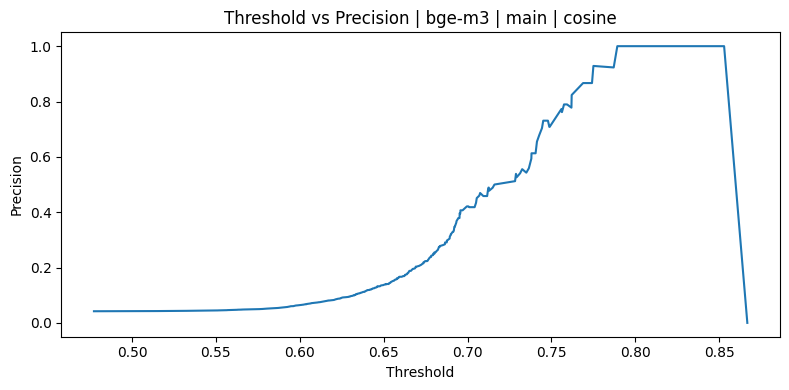

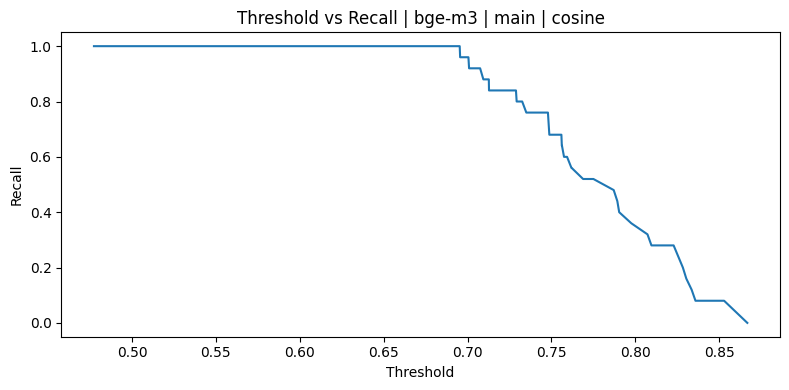

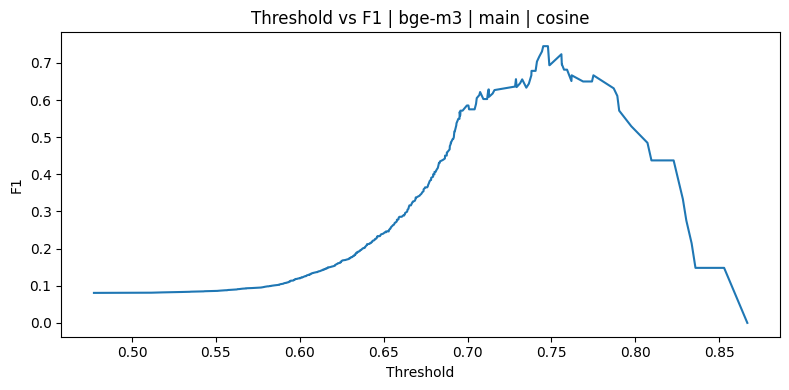

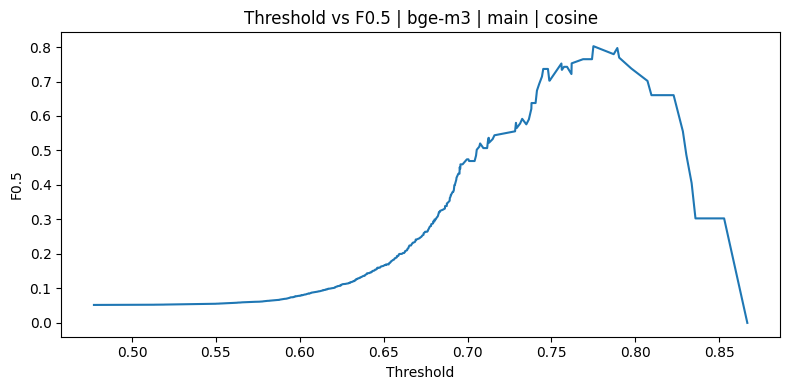

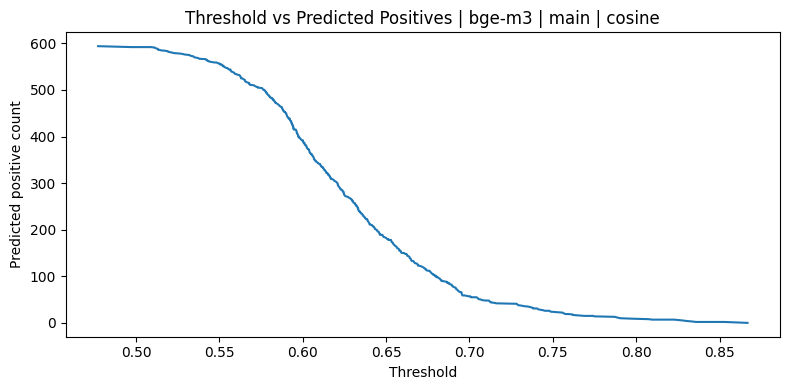

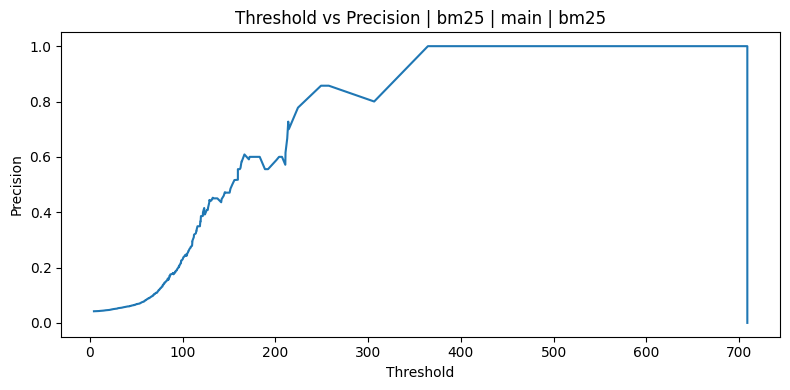

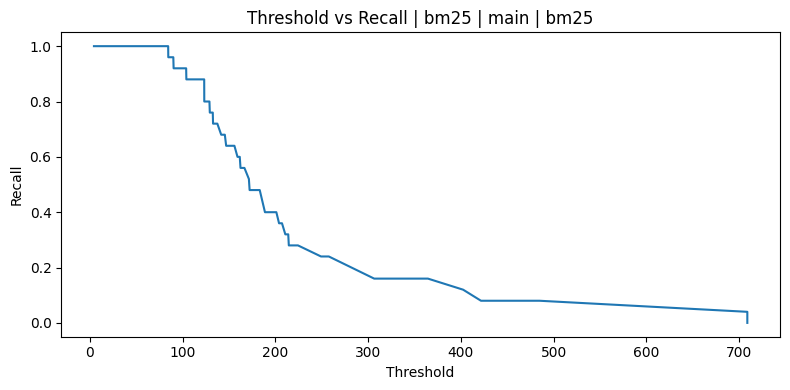

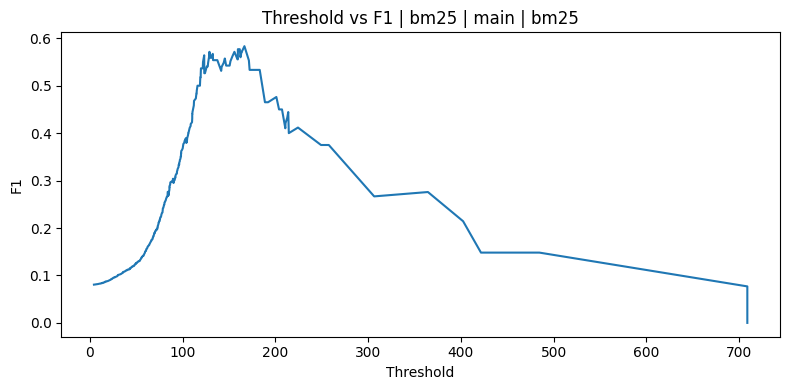

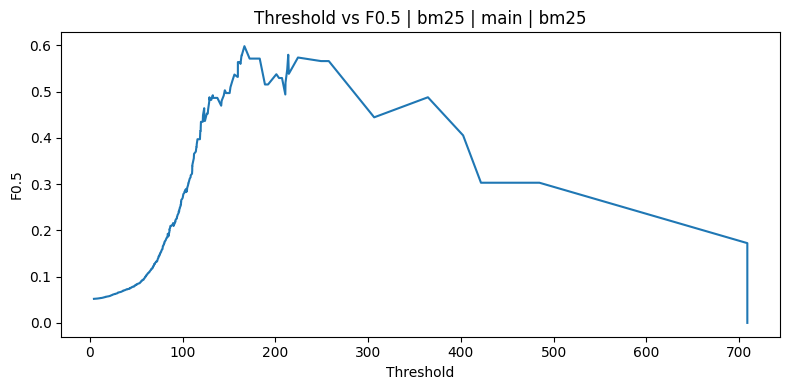

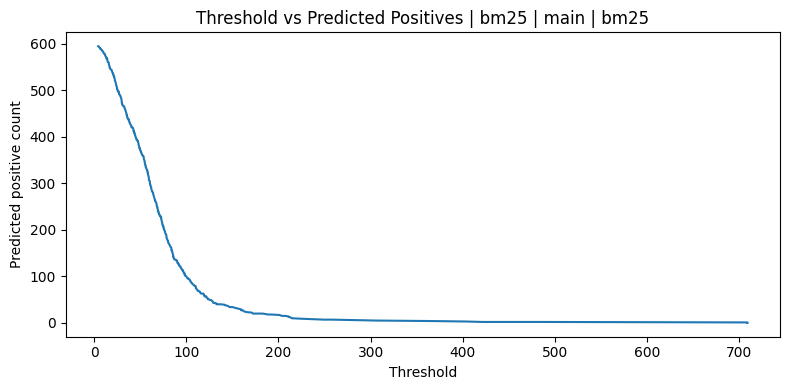

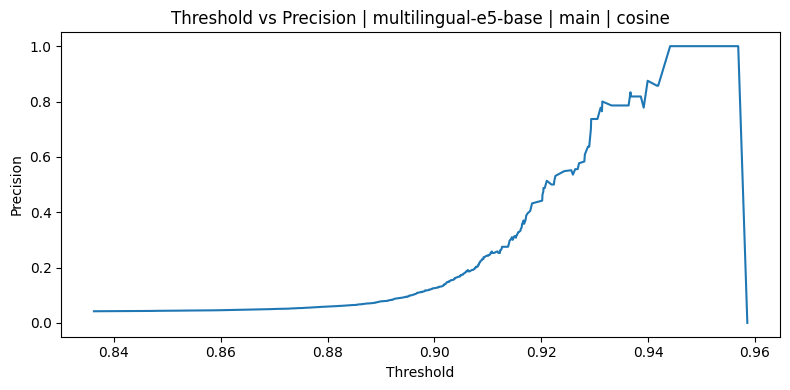

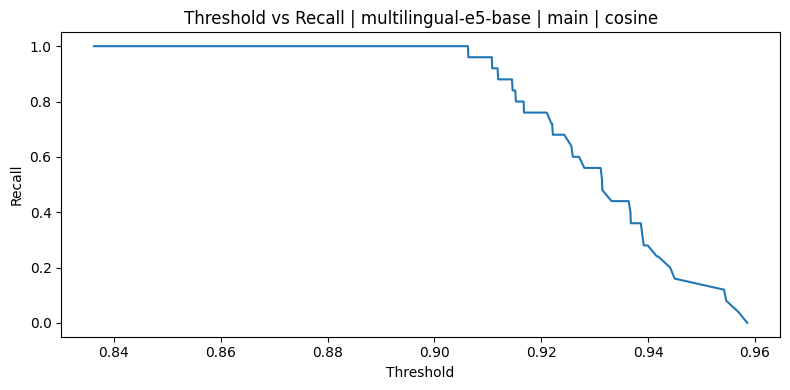

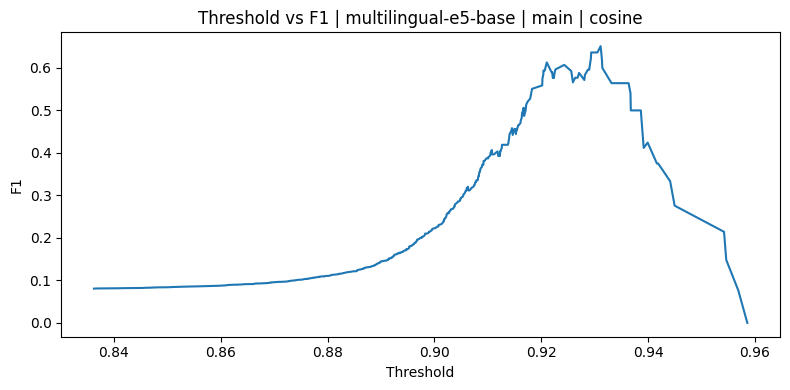

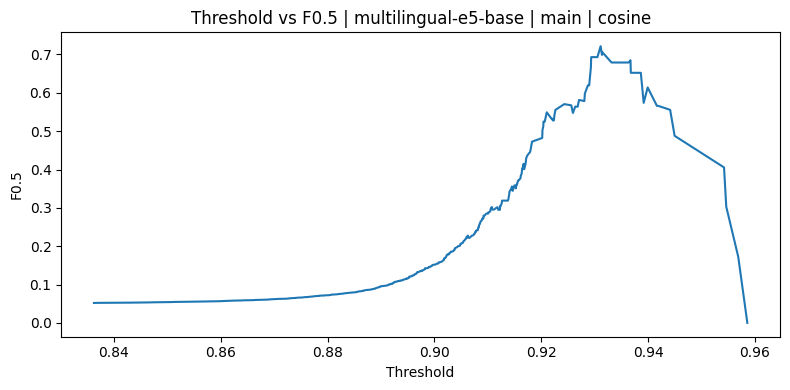

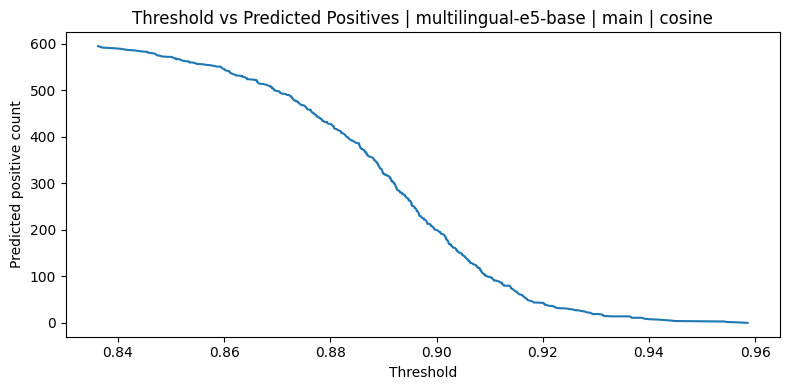

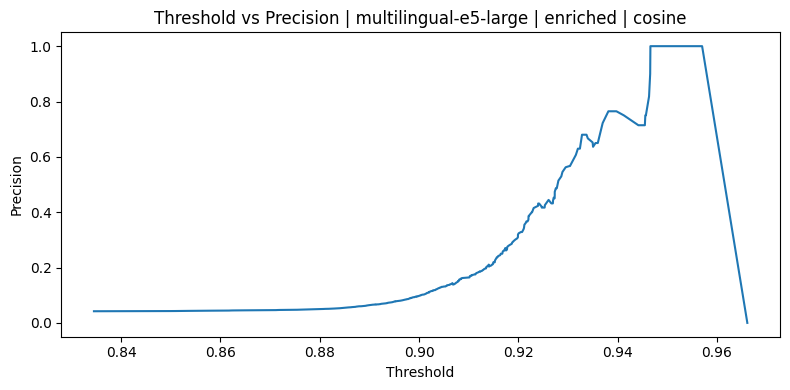

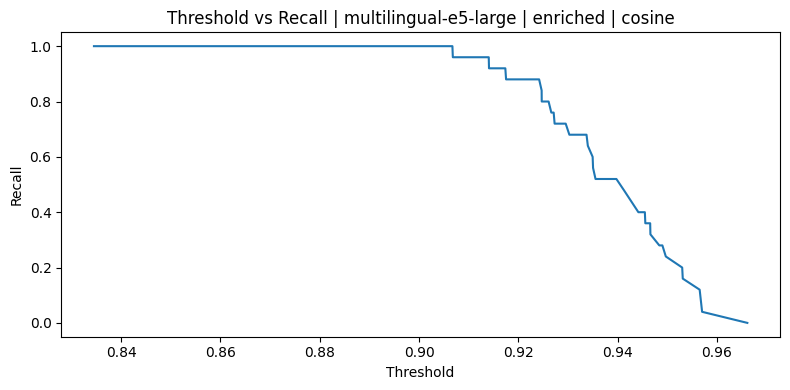

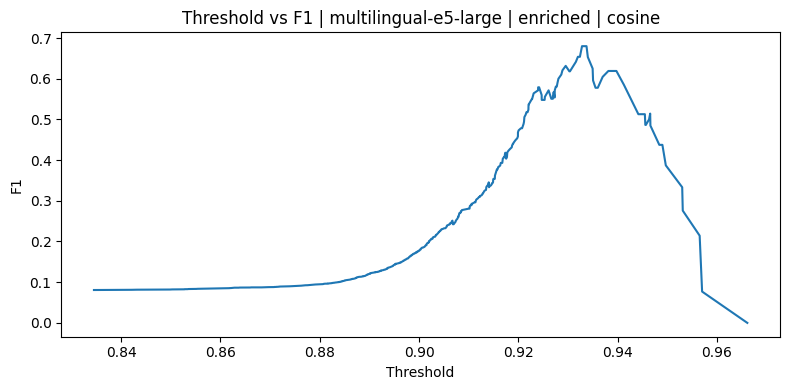

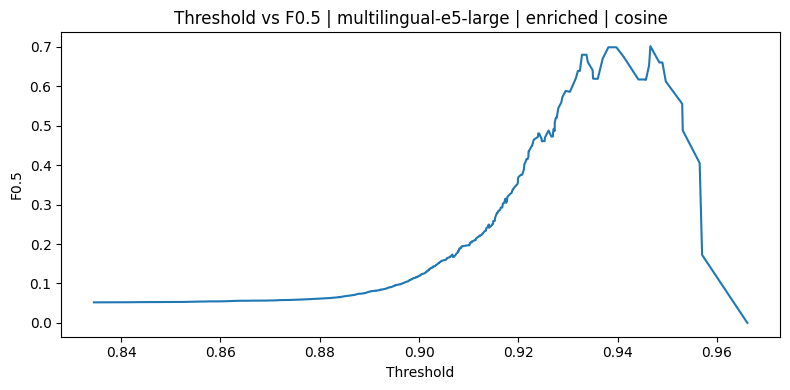

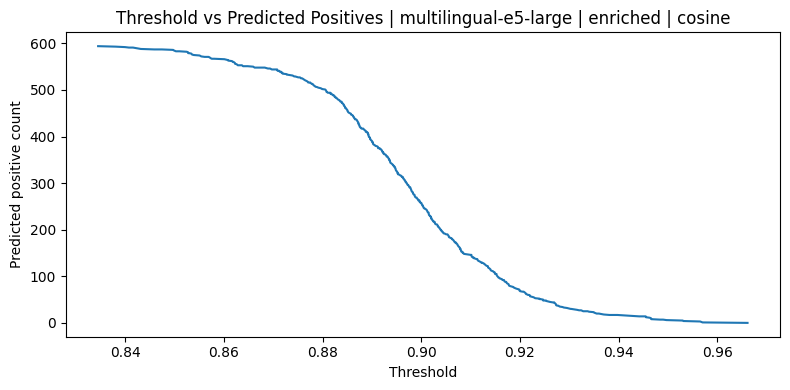

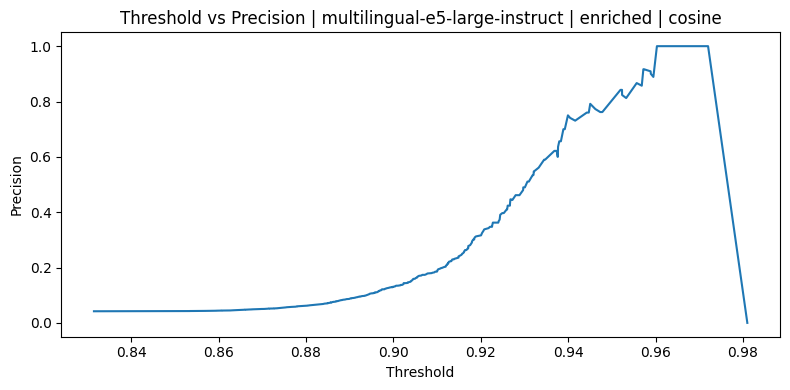

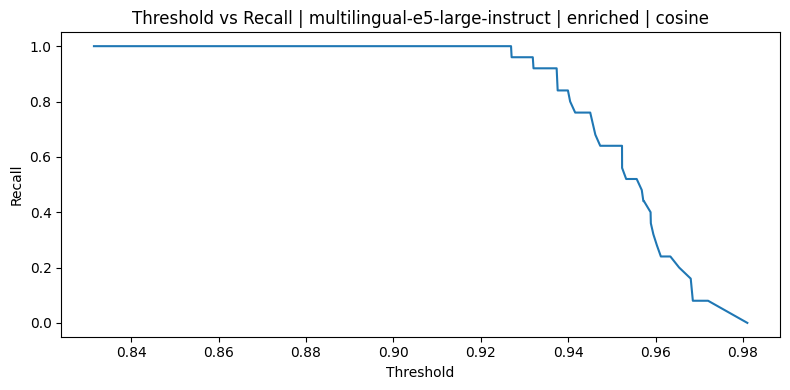

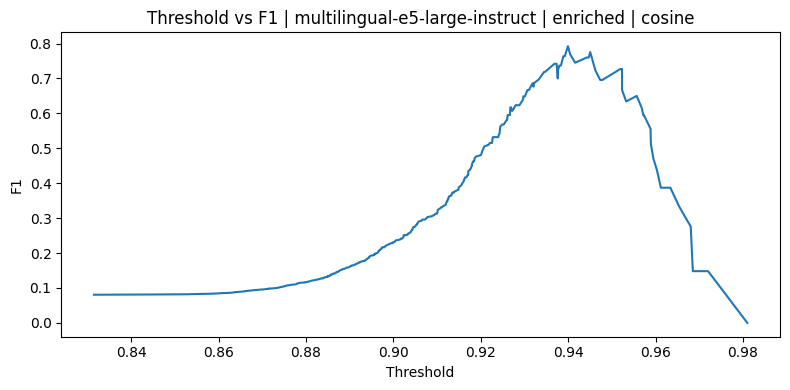

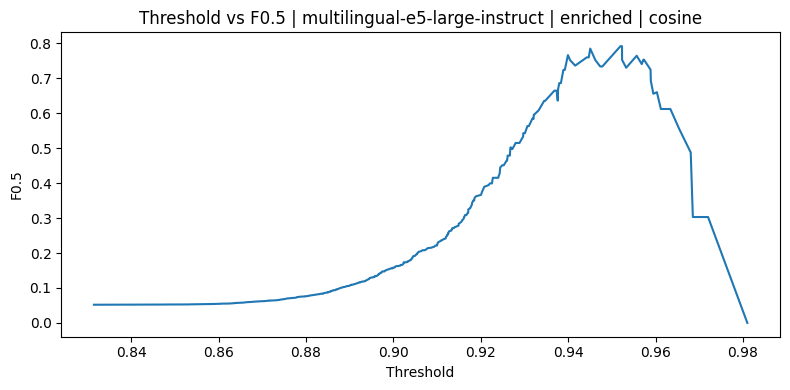

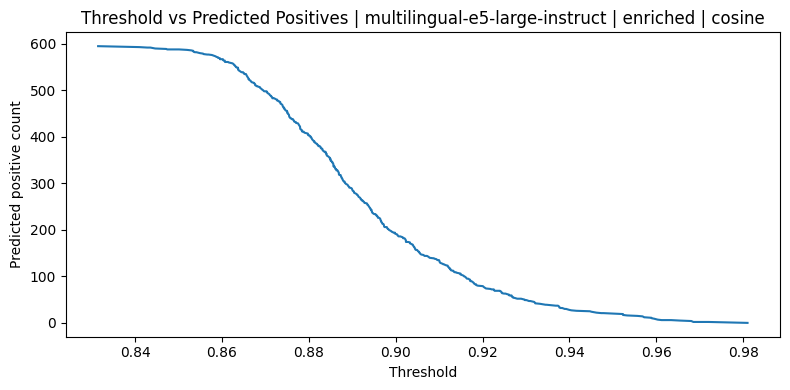

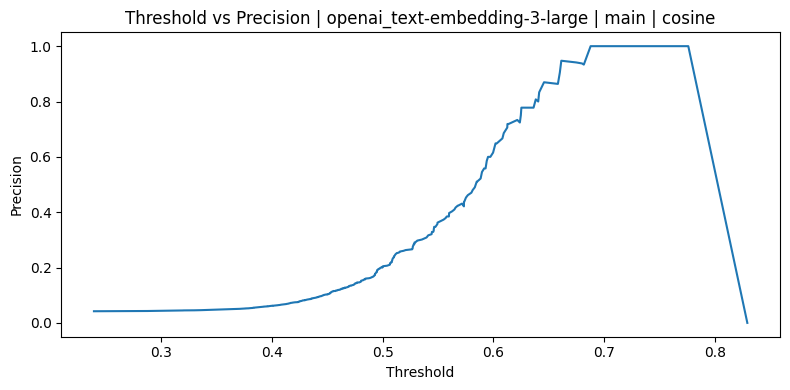

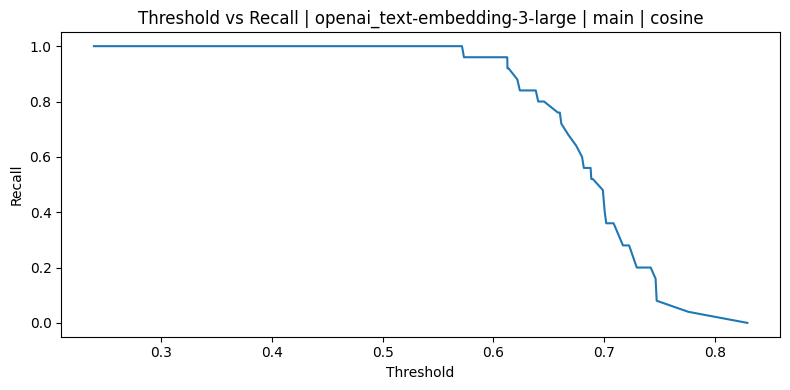

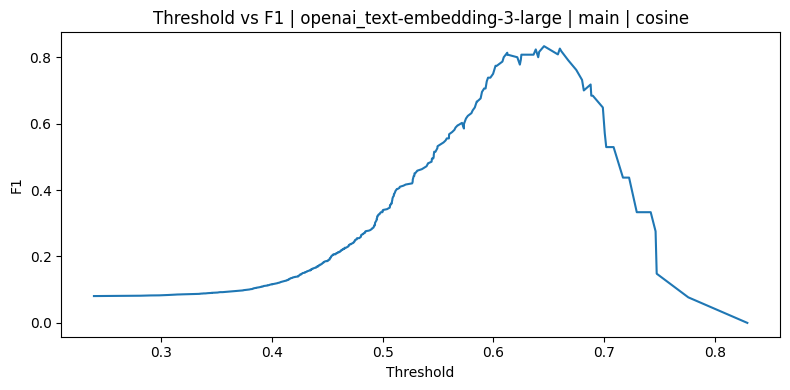

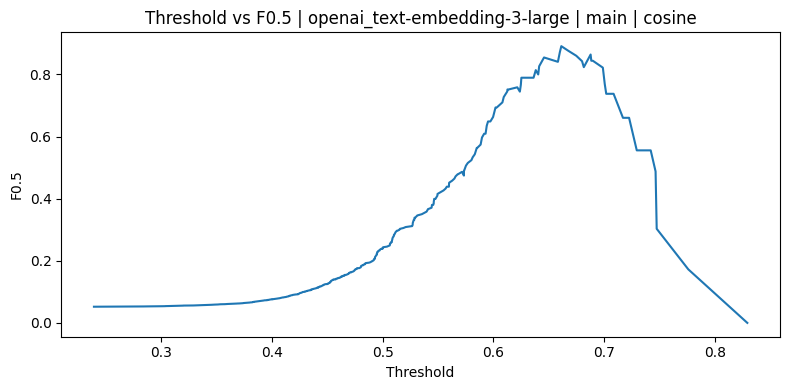

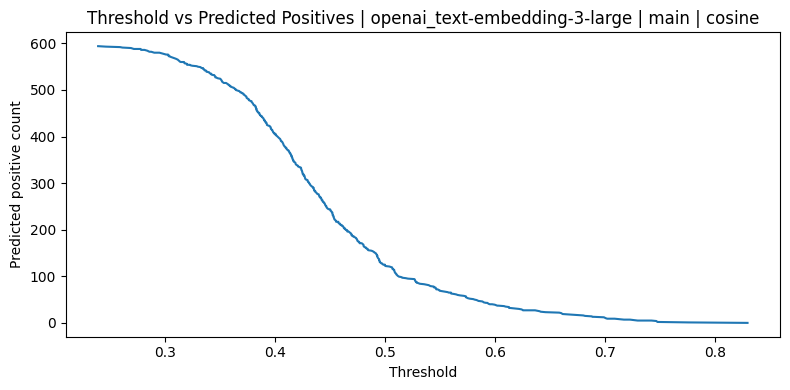

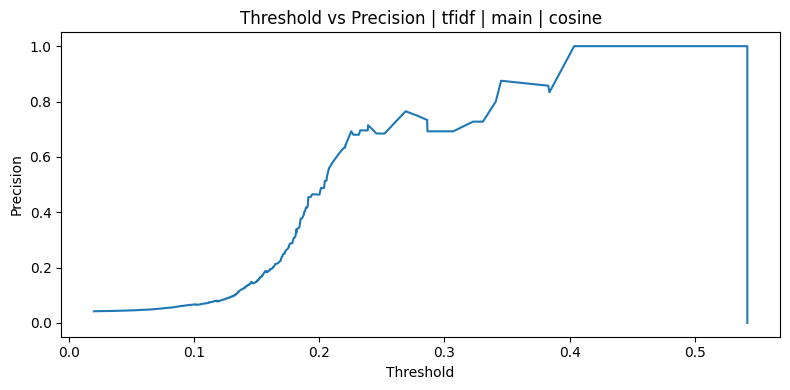

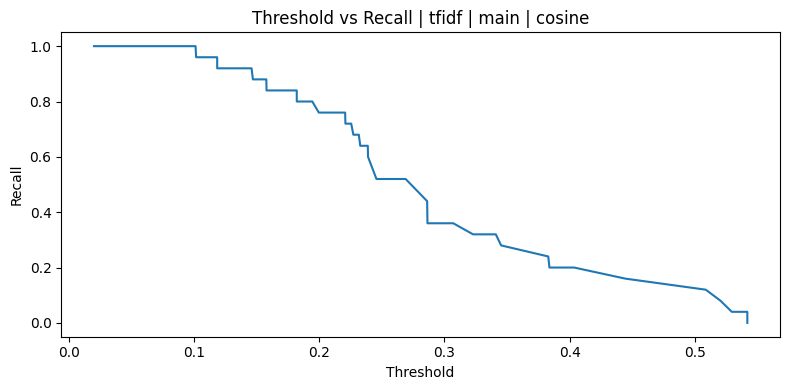

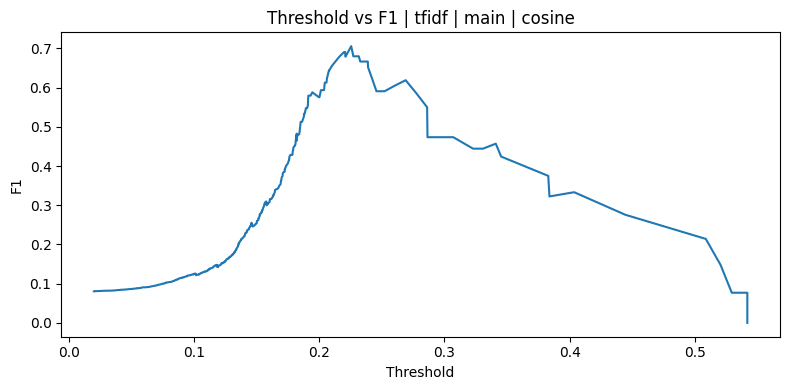

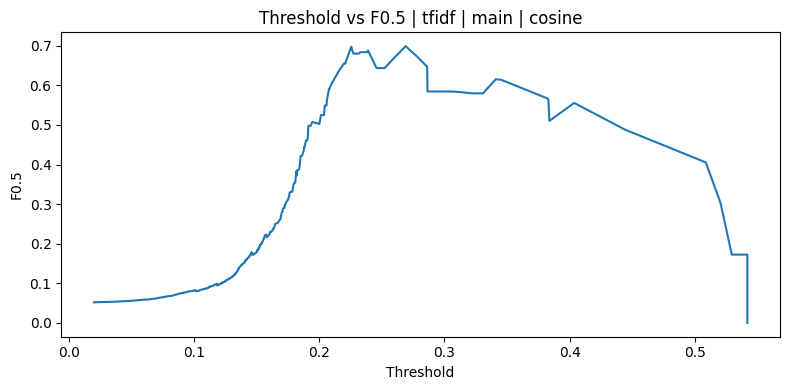

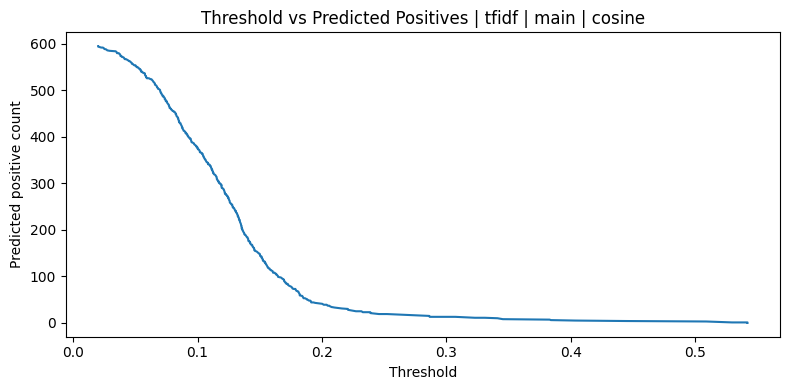

In [19]:
# Cell 11 - Plot threshold behavior for each shortlisted configuration

for (model_name, text_variant, similarity_metric), group_df in threshold_scan_dev_df.groupby(
    ["model_name", "text_variant", "similarity_metric"]
):
    plot_df = group_df.sort_values("threshold").reset_index(drop=True)
    base_name = f"{slugify_name(model_name)}__{slugify_name(text_variant)}__{slugify_name(similarity_metric)}"

    plt.figure(figsize=(8, 4))
    plt.plot(plot_df["threshold"], plot_df["precision"])
    plt.xlabel("Threshold")
    plt.ylabel("Precision")
    plt.title(f"Threshold vs Precision | {model_name} | {text_variant} | {similarity_metric}")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"threshold_precision__{base_name}.png", dpi=150)
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(plot_df["threshold"], plot_df["recall"])
    plt.xlabel("Threshold")
    plt.ylabel("Recall")
    plt.title(f"Threshold vs Recall | {model_name} | {text_variant} | {similarity_metric}")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"threshold_recall__{base_name}.png", dpi=150)
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(plot_df["threshold"], plot_df["f1"])
    plt.xlabel("Threshold")
    plt.ylabel("F1")
    plt.title(f"Threshold vs F1 | {model_name} | {text_variant} | {similarity_metric}")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"threshold_f1__{base_name}.png", dpi=150)
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(plot_df["threshold"], plot_df["f05"])
    plt.xlabel("Threshold")
    plt.ylabel("F0.5")
    plt.title(f"Threshold vs F0.5 | {model_name} | {text_variant} | {similarity_metric}")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"threshold_f05__{base_name}.png", dpi=150)
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(plot_df["threshold"], plot_df["predicted_positive_count"])
    plt.xlabel("Threshold")
    plt.ylabel("Predicted positive count")
    plt.title(f"Threshold vs Predicted Positives | {model_name} | {text_variant} | {similarity_metric}")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"threshold_predicted_positive_count__{base_name}.png", dpi=150)
    plt.show()

### Threshold selection support table

The final locked threshold should not feel arbitrary.

This support table adds practical decision flags to the candidate thresholds:

- whether reviewer load is reasonable
- whether precision is strong
- whether recall remains minimally usable

These flags do **not** replace human judgment.  
They make the final lock step more transparent and easier to justify in the thesis.

In [20]:
# Cell 12 - Build a threshold selection support table

selection_support_df = candidate_thresholds_dev_df.copy()

selection_support_df["reviewer_load_reasonable"] = selection_support_df["predicted_positive_count"].between(6, 22)
selection_support_df["precision_strong"] = selection_support_df["precision"] >= 0.80
selection_support_df["recall_minimum_ok"] = selection_support_df["recall"] >= 0.30
selection_support_df["very_low_recall"] = selection_support_df["recall"] < 0.25
selection_support_df["very_high_reviewer_load"] = selection_support_df["predicted_positive_count"] > 22

selection_support_df = selection_support_df.sort_values(
    ["model_name", "text_variant", "similarity_metric", "selection_rule"]
).reset_index(drop=True)

selection_support_df.to_csv(THRESHOLD_SELECTION_SUPPORT_CSV_PATH, index=False, encoding="utf-8")

display(selection_support_df[[
    "model_name",
    "text_variant",
    "similarity_metric",
    "selection_rule",
    "threshold",
    "precision",
    "recall",
    "f1",
    "f05",
    "predicted_positive_count",
    "reviewer_load_reasonable",
    "precision_strong",
    "recall_minimum_ok",
    "very_low_recall",
    "very_high_reviewer_load",
]])

,model_name,text_variant,similarity_metric,selection_rule,threshold,precision,recall,f1,f05,predicted_positive_count,reviewer_load_reasonable,precision_strong,recall_minimum_ok,very_low_recall,very_high_reviewer_load
0,bge-m3,main,cosine,max_f05,0.775048,0.928571,0.52,0.666667,0.802469,14,True,True,True,False,False
1,bge-m3,main,cosine,max_f1,0.745144,0.730769,0.76,0.745098,0.736434,26,False,False,True,False,True
2,bge-m3,main,cosine,precision_floor_080,0.762096,0.823529,0.56,0.666667,0.752688,17,True,True,True,False,False
3,bge-m3,main,cosine,reviewer_load_target_10,0.790416,1.000000,0.40,0.571429,0.769231,10,True,True,True,False,False
4,bm25,main,bm25,max_f05,166.675903,0.608696,0.56,0.583333,0.598291,23,False,False,True,False,True
5,bm25,main,bm25,max_f1,166.675903,0.608696,0.56,0.583333,0.598291,23,False,False,True,False,True
6,bm25,main,bm25,precision_floor_080,249.244461,0.857143,0.24,0.375000,0.566038,7,True,True,False,True,False
7,bm25,main,bm25,reviewer_load_target_10,214.534180,0.700000,0.28,0.400000,0.538462,10,True,False,False,False,False
8,multilingual-e5-base,main,cosine,max_f05,0.931097,0.777778,0.56,0.651163,0.721649,18,True,False,True,False,False
9,multilingual-e5-base,main,cosine,max_f1,0.931097,0.777778,0.56,0.651163,0.721649,18,True,False,True,False,False


### Lock one threshold per shortlisted configuration

The development-set candidate thresholds are now converted into one **locked threshold** per shortlisted configuration.

This is still a **development-only decision**.

The lock step is intentionally explicit rather than fully automatic, because threshold choice is partly methodological and partly practical.

Selection principles used here:

- prefer **max_f1** when it provides the clearest overall balance and reviewer load remains practical
- prefer **max_f05** when a more precision-oriented operating point is more appropriate
- prefer **reviewer_load_target_10** when max-F1 becomes too reviewer-heavy for realistic PoC use
- avoid extremely low-recall thresholds unless there is a strong precision-driven reason to keep them

The detailed rationale is captured in the notebook prose and in the candidate threshold tables, rather than repeated as long text inside every output row.

In [22]:
# Cell 13 - Select one locked threshold per shortlisted configuration using explicit rules

LOCKED_THRESHOLD_RULES = {
    ("openai_text-embedding-3-large", "main", "cosine"): "max_f05",
    ("multilingual-e5-large-instruct", "enriched", "cosine"): "max_f05",
    ("bge-m3", "main", "cosine"): "max_f05",
    ("multilingual-e5-large", "enriched", "cosine"): "precision_floor_080",
    ("multilingual-e5-base", "main", "cosine"): "max_f1",
    ("tfidf", "main", "cosine"): "max_f05",
    ("bm25", "main", "bm25"): "max_f1",
}

LOCKED_THRESHOLD_NOTES = {
    ("openai_text-embedding-3-large", "main", "cosine"):
        "Selected max_f05 because it preserves very strong precision-recall balance while keeping reviewer load below the too-heavy max_f1 option.",
    ("multilingual-e5-large-instruct", "enriched", "cosine"):
        "Selected max_f05 because max_f1 becomes reviewer-heavy, while max_f05 keeps strong precision and still retains good recall.",
    ("bge-m3", "main", "cosine"):
        "Selected max_f05 because it improves precision substantially over max_f1 and keeps reviewer load at a practical level.",
    ("multilingual-e5-large", "enriched", "cosine"):
        "Selected precision_floor_080 because it provides a conservative operating point with strong precision and practical reviewer load.",
    ("multilingual-e5-base", "main", "cosine"):
        "Selected max_f1 because max_f1 and max_f05 are identical here, and this threshold gives the strongest balanced development-set decision quality.",
    ("tfidf", "main", "cosine"):
        "Selected max_f05 because it is more practical than the reviewer-heavy max_f1 threshold while still giving a usable lexical baseline.",
    ("bm25", "main", "bm25"):
        "Selected max_f1 because the BM25 baseline is retained mainly for comparison, and this threshold gives its best balanced development-set result.",
}

selected_threshold_rows = []

for (model_name, text_variant, similarity_metric), selection_rule in LOCKED_THRESHOLD_RULES.items():
    match_df = candidate_thresholds_dev_df[
        (candidate_thresholds_dev_df["model_name"] == model_name) &
        (candidate_thresholds_dev_df["text_variant"] == text_variant) &
        (candidate_thresholds_dev_df["similarity_metric"] == similarity_metric) &
        (candidate_thresholds_dev_df["selection_rule"] == selection_rule)
    ].copy()

    if match_df.empty:
        raise ValueError(
            f"No candidate threshold found for model={model_name}, text_variant={text_variant}, "
            f"similarity_metric={similarity_metric}, selection_rule={selection_rule}."
        )

    selected_row = match_df.iloc[0].to_dict()
    selected_row["selection_note"] = LOCKED_THRESHOLD_NOTES[(model_name, text_variant, similarity_metric)]
    selected_threshold_rows.append(selected_row)

selected_thresholds_df = pd.DataFrame(selected_threshold_rows)

selected_thresholds_df = selected_thresholds_df[[
    "model_name",
    "text_variant",
    "similarity_metric",
    "selection_rule",
    "selection_note",
    "threshold",
    "precision",
    "recall",
    "f1",
    "f05",
    "accuracy",
    "specificity",
    "predicted_positive_count",
    "tp",
    "fp",
    "fn",
    "tn",
]].copy()

selected_thresholds_df = selected_thresholds_df.sort_values(
    ["f1", "f05", "precision", "recall"],
    ascending=[False, False, False, False]
).reset_index(drop=True)

selected_thresholds_df.to_csv(SELECTED_THRESHOLDS_CSV_PATH, index=False, encoding="utf-8")

print("Saved selected thresholds to:", SELECTED_THRESHOLDS_CSV_PATH)
display(selected_thresholds_df)

Saved selected thresholds to: C:\Users\user\Downloads\curriculum-overlap-poc\reports\tables\thresholds\selected_thresholds_for_test.csv


,model_name,text_variant,similarity_metric,selection_rule,selection_note,threshold,precision,recall,f1,f05,accuracy,specificity,predicted_positive_count,tp,fp,fn,tn
0,openai_text-embedding-3-large,main,cosine,max_f05,Selected max_f05 because it preserves very strong precision-recall balance while keeping reviewer load below the too-heavy max_f1 option.,0.661284,0.947368,0.72,0.818182,0.891089,0.986555,0.998246,19,18,1,7,569
1,multilingual-e5-large-instruct,enriched,cosine,max_f05,"Selected max_f05 because max_f1 becomes reviewer-heavy, while max_f05 keeps strong precision and still retains good recall.",0.951981,0.842105,0.64,0.727273,0.792079,0.979832,0.994737,19,16,3,9,567
2,bge-m3,main,cosine,max_f05,Selected max_f05 because it improves precision substantially over max_f1 and keeps reviewer load at a practical level.,0.775048,0.928571,0.52,0.666667,0.802469,0.978151,0.998246,14,13,1,12,569
3,multilingual-e5-base,main,cosine,max_f1,"Selected max_f1 because max_f1 and max_f05 are identical here, and this threshold gives the strongest balanced development-set decision quality.",0.931097,0.777778,0.56,0.651163,0.721649,0.974790,0.992982,18,14,4,11,566
4,tfidf,main,cosine,max_f05,Selected max_f05 because it is more practical than the reviewer-heavy max_f1 threshold while still giving a usable lexical baseline.,0.269003,0.764706,0.52,0.619048,0.698925,0.973109,0.992982,17,13,4,12,566
5,bm25,main,bm25,max_f1,"Selected max_f1 because the BM25 baseline is retained mainly for comparison, and this threshold gives its best balanced development-set result.",166.675903,0.608696,0.56,0.583333,0.598291,0.966387,0.984211,23,14,9,11,561
6,multilingual-e5-large,enriched,cosine,precision_floor_080,Selected precision_floor_080 because it provides a conservative operating point with strong precision and practical reviewer load.,0.946540,0.900000,0.36,0.514286,0.692308,0.971429,0.998246,10,9,1,16,569


### Evaluate locked thresholds on the test split

The selected thresholds are now applied unchanged to the **held-out test split**.

Important:

- the test set was **not** used to choose these thresholds
- test metrics therefore remain a genuine held-out evaluation
- because the test split contains only **8 positive pairs**, the results are informative but still somewhat unstable

For that reason, the test table should be treated as one part of the final evidence, not as the sole basis for the final thesis recommendation.

In [23]:
# Cell 14 - Evaluate locked thresholds on the test split

test_scores_df = evaluation_scores_df[evaluation_scores_df["split"] == "test"].copy()

if test_scores_df.empty:
    raise ValueError("Test split is empty after shortlist filtering.")

test_evaluation_rows = []

for _, threshold_row in selected_thresholds_df.iterrows():
    model_name = threshold_row["model_name"]
    text_variant = threshold_row["text_variant"]
    similarity_metric = threshold_row["similarity_metric"]
    locked_threshold = float(threshold_row["threshold"])

    group_df = test_scores_df[
        (test_scores_df["model_name"] == model_name) &
        (test_scores_df["text_variant"] == text_variant) &
        (test_scores_df["similarity_metric"] == similarity_metric)
    ].copy()

    if group_df.empty:
        raise ValueError(
            f"No test rows found for model={model_name}, text_variant={text_variant}, similarity_metric={similarity_metric}."
        )

    y_true = group_df["overlap_label_binary"].to_numpy()
    y_score = group_df["similarity_score"].to_numpy()

    metrics = compute_threshold_metrics(y_true=y_true, y_score=y_score, threshold=locked_threshold)

    test_evaluation_rows.append({
        "model_name": model_name,
        "text_variant": text_variant,
        "similarity_metric": similarity_metric,
        "selection_rule": threshold_row["selection_rule"],
        "selection_note": threshold_row["selection_note"],
        "locked_threshold": locked_threshold,
        "pair_count_test": len(group_df),
        "positive_count_test": int(group_df["overlap_label_binary"].sum()),
        **metrics,
    })

test_evaluation_df = pd.DataFrame(test_evaluation_rows)
test_evaluation_df.to_csv(TEST_EVALUATION_CSV_PATH, index=False, encoding="utf-8")

print("Saved test evaluation table to:", TEST_EVALUATION_CSV_PATH)
display(test_evaluation_df[[
    "model_name",
    "text_variant",
    "similarity_metric",
    "selection_rule",
    "locked_threshold",
    "precision",
    "recall",
    "f1",
    "f05",
    "predicted_positive_count",
    "fp",
    "fn",
    "tp",
]])

Saved test evaluation table to: C:\Users\user\Downloads\curriculum-overlap-poc\reports\tables\thresholds\test_evaluation_locked_thresholds.csv


,model_name,text_variant,similarity_metric,selection_rule,locked_threshold,precision,recall,f1,f05,predicted_positive_count,fp,fn,tp
0,openai_text-embedding-3-large,main,cosine,max_f05,0.661284,1.000000,0.666667,0.800000,0.909091,6,0,3,6
1,multilingual-e5-large-instruct,enriched,cosine,max_f05,0.951981,1.000000,0.777778,0.875000,0.945946,7,0,2,7
2,bge-m3,main,cosine,max_f05,0.775048,0.666667,0.222222,0.333333,0.476190,3,1,7,2
3,multilingual-e5-base,main,cosine,max_f1,0.931097,0.714286,0.555556,0.625000,0.675676,7,2,4,5
4,tfidf,main,cosine,max_f05,0.269003,0.142857,0.555556,0.227273,0.167785,35,30,4,5
5,bm25,main,bm25,max_f1,166.675903,0.416667,0.555556,0.476190,0.438596,12,7,4,5
6,multilingual-e5-large,enriched,cosine,precision_floor_080,0.946540,1.000000,0.444444,0.615385,0.800000,4,0,5,4


### Compare development and test stability

This comparison shows how each locked threshold behaves from development to test.

The goal is not only to find the highest development F1, but also to see:

- which operating points generalize best
- which thresholds become unstable on test
- which models remain practically usable under held-out evaluation
- how Notebook 03 ranking evidence aligns with Notebook 04 decision behavior

In [24]:
# Cell 15 - Compare development and test metrics for the locked thresholds

dev_locked_df = selected_thresholds_df.rename(columns={
    "threshold": "dev_locked_threshold",
    "precision": "dev_precision",
    "recall": "dev_recall",
    "f1": "dev_f1",
    "f05": "dev_f05",
    "accuracy": "dev_accuracy",
    "specificity": "dev_specificity",
    "predicted_positive_count": "dev_predicted_positive_count",
    "tp": "dev_tp",
    "fp": "dev_fp",
    "fn": "dev_fn",
    "tn": "dev_tn",
})

test_locked_df = test_evaluation_df.rename(columns={
    "precision": "test_precision",
    "recall": "test_recall",
    "f1": "test_f1",
    "f05": "test_f05",
    "accuracy": "test_accuracy",
    "specificity": "test_specificity",
    "predicted_positive_count": "test_predicted_positive_count",
    "tp": "test_tp",
    "fp": "test_fp",
    "fn": "test_fn",
    "tn": "test_tn",
})

dev_test_comparison_df = dev_locked_df.merge(
    test_locked_df,
    on=["model_name", "text_variant", "similarity_metric", "selection_rule", "selection_note"],
    how="inner"
)

shortlist_evidence_df = shortlist_df[[
    "model_name",
    "text_variant",
    "similarity_metric",
    "shortlist_rank",
    "average_precision",
    "roc_auc",
]].drop_duplicates().copy()

dev_test_comparison_df = dev_test_comparison_df.merge(
    shortlist_evidence_df,
    on=["model_name", "text_variant", "similarity_metric"],
    how="left"
)

dev_test_comparison_df["precision_delta_test_minus_dev"] = (
    dev_test_comparison_df["test_precision"] - dev_test_comparison_df["dev_precision"]
)
dev_test_comparison_df["recall_delta_test_minus_dev"] = (
    dev_test_comparison_df["test_recall"] - dev_test_comparison_df["dev_recall"]
)
dev_test_comparison_df["f1_delta_test_minus_dev"] = (
    dev_test_comparison_df["test_f1"] - dev_test_comparison_df["dev_f1"]
)
dev_test_comparison_df["f05_delta_test_minus_dev"] = (
    dev_test_comparison_df["test_f05"] - dev_test_comparison_df["dev_f05"]
)

dev_test_comparison_df.to_csv(DEV_TEST_COMPARISON_CSV_PATH, index=False, encoding="utf-8")

print("Saved dev/test threshold comparison to:", DEV_TEST_COMPARISON_CSV_PATH)

display(dev_test_comparison_df[[
    "model_name",
    "text_variant",
    "similarity_metric",
    "selection_rule",
    "shortlist_rank",
    "average_precision",
    "roc_auc",
    "dev_locked_threshold",
    "dev_precision",
    "dev_recall",
    "dev_f1",
    "test_precision",
    "test_recall",
    "test_f1",
    "test_f05",
    "f1_delta_test_minus_dev",
    "dev_predicted_positive_count",
    "test_predicted_positive_count",
]])

Saved dev/test threshold comparison to: C:\Users\user\Downloads\curriculum-overlap-poc\reports\tables\thresholds\dev_test_threshold_comparison.csv


,model_name,text_variant,similarity_metric,selection_rule,shortlist_rank,average_precision,roc_auc,dev_locked_threshold,dev_precision,dev_recall,dev_f1,test_precision,test_recall,test_f1,test_f05,f1_delta_test_minus_dev,dev_predicted_positive_count,test_predicted_positive_count
0,openai_text-embedding-3-large,main,cosine,max_f05,1,0.919470,0.994877,0.661284,0.947368,0.72,0.818182,1.000000,0.666667,0.800000,0.909091,-0.018182,19,6
1,multilingual-e5-large-instruct,enriched,cosine,max_f05,2,0.842588,0.991298,0.951981,0.842105,0.64,0.727273,1.000000,0.777778,0.875000,0.945946,0.147727,19,7
2,bge-m3,main,cosine,max_f05,3,0.816187,0.987018,0.775048,0.928571,0.52,0.666667,0.666667,0.222222,0.333333,0.476190,-0.333333,14,3
3,multilingual-e5-base,main,cosine,max_f1,5,0.676364,0.967789,0.931097,0.777778,0.56,0.651163,0.714286,0.555556,0.625000,0.675676,-0.026163,18,7
4,tfidf,main,cosine,max_f05,6,0.668360,0.931298,0.269003,0.764706,0.52,0.619048,0.142857,0.555556,0.227273,0.167785,-0.391775,17,35
5,bm25,main,bm25,max_f1,7,0.608462,0.962316,166.675903,0.608696,0.56,0.583333,0.416667,0.555556,0.476190,0.438596,-0.107143,23,12
6,multilingual-e5-large,enriched,cosine,precision_floor_080,4,0.704587,0.967298,0.946540,0.900000,0.36,0.514286,1.000000,0.444444,0.615385,0.800000,0.101099,10,4


### Practical interpretation for the PoC

A good threshold is not only one that scores well mathematically.

It should also be practical for a curriculum reviewer:

- predicted positive count should be manageable
- false positives should not dominate the review load
- threshold behavior should be reasonably stable
- the reported overlaps should be interpretable enough to support the later UI

This table is therefore ordered using a **balanced practical view** rather than raw test performance alone.

That is important because the held-out test split contains only **8 positive pairs**.  
A configuration should not appear to be the overall winner only because it performs best on that very small subset.

In [25]:
# Cell 16 - Practical threshold interpretation table

practical_interpretation_df = dev_test_comparison_df[[
    "model_name",
    "text_variant",
    "similarity_metric",
    "selection_rule",
    "shortlist_rank",
    "average_precision",
    "roc_auc",
    "dev_locked_threshold",
    "dev_precision",
    "dev_recall",
    "dev_f1",
    "dev_f05",
    "dev_predicted_positive_count",
    "test_precision",
    "test_recall",
    "test_f1",
    "test_f05",
    "test_predicted_positive_count",
    "test_fp",
    "test_fn",
    "test_tp",
]].copy()

practical_interpretation_df = practical_interpretation_df.sort_values(
    [
        "shortlist_rank",
        "average_precision",
        "dev_f1",
        "test_f1",
        "test_f05",
        "test_precision",
    ],
    ascending=[True, False, False, False, False, False]
).reset_index(drop=True)

practical_interpretation_df.to_csv(
    PRACTICAL_INTERPRETATION_CSV_PATH,
    index=False,
    encoding="utf-8"
)

print("Saved practical interpretation table to:", PRACTICAL_INTERPRETATION_CSV_PATH)
display(practical_interpretation_df)

Saved practical interpretation table to: C:\Users\user\Downloads\curriculum-overlap-poc\reports\tables\thresholds\practical_threshold_interpretation.csv


,model_name,text_variant,similarity_metric,selection_rule,shortlist_rank,average_precision,roc_auc,dev_locked_threshold,dev_precision,dev_recall,dev_f1,dev_f05,dev_predicted_positive_count,test_precision,test_recall,test_f1,test_f05,test_predicted_positive_count,test_fp,test_fn,test_tp
0,openai_text-embedding-3-large,main,cosine,max_f05,1,0.919470,0.994877,0.661284,0.947368,0.72,0.818182,0.891089,19,1.000000,0.666667,0.800000,0.909091,6,0,3,6
1,multilingual-e5-large-instruct,enriched,cosine,max_f05,2,0.842588,0.991298,0.951981,0.842105,0.64,0.727273,0.792079,19,1.000000,0.777778,0.875000,0.945946,7,0,2,7
2,bge-m3,main,cosine,max_f05,3,0.816187,0.987018,0.775048,0.928571,0.52,0.666667,0.802469,14,0.666667,0.222222,0.333333,0.476190,3,1,7,2
3,multilingual-e5-large,enriched,cosine,precision_floor_080,4,0.704587,0.967298,0.946540,0.900000,0.36,0.514286,0.692308,10,1.000000,0.444444,0.615385,0.800000,4,0,5,4
4,multilingual-e5-base,main,cosine,max_f1,5,0.676364,0.967789,0.931097,0.777778,0.56,0.651163,0.721649,18,0.714286,0.555556,0.625000,0.675676,7,2,4,5
5,tfidf,main,cosine,max_f05,6,0.668360,0.931298,0.269003,0.764706,0.52,0.619048,0.698925,17,0.142857,0.555556,0.227273,0.167785,35,30,4,5
6,bm25,main,bm25,max_f1,7,0.608462,0.962316,166.675903,0.608696,0.56,0.583333,0.598291,23,0.416667,0.555556,0.476190,0.438596,12,7,4,5


### Final threshold recommendation

The final recommendation should not be chosen from development AP alone.

It also should not be chosen from the held-out test split alone.

Instead, the final thesis-oriented recommendation should combine:

- **Notebook 03 ranking quality**
- **Notebook 04 threshold behavior on development**
- **held-out test behavior**
- **practical reviewer usability**

Because the test split contains only **8 positives**, the notebook reports:

1. a **primary thesis-oriented recommendation**
2. a **conservative alternative**

The primary recommendation is the best overall choice for the PoC and thesis interpretation.

The conservative alternative is included for settings where stronger false-positive control is preferred, even if that means using a stricter operating point.

In [26]:
# Cell 17 - Final threshold recommendation with thesis-oriented primary and conservative alternative

final_ranking_df = dev_test_comparison_df[[
    "model_name",
    "text_variant",
    "similarity_metric",
    "selection_rule",
    "shortlist_rank",
    "average_precision",
    "roc_auc",
    "dev_locked_threshold",
    "dev_precision",
    "dev_recall",
    "dev_f1",
    "dev_f05",
    "test_precision",
    "test_recall",
    "test_f1",
    "test_f05",
    "dev_predicted_positive_count",
    "test_predicted_positive_count",
]].copy()

final_ranking_df = final_ranking_df.sort_values(
    ["shortlist_rank", "average_precision", "dev_f1", "test_f1", "test_f05"],
    ascending=[True, False, False, False, False]
).reset_index(drop=True)

print("Balanced final comparison table:")
display(final_ranking_df)

balanced_candidates_df = dev_test_comparison_df.copy()

primary_pool_df = balanced_candidates_df[
    (balanced_candidates_df["shortlist_rank"] <= 3) &
    (balanced_candidates_df["dev_f1"] >= 0.65) &
    (balanced_candidates_df["test_f1"] >= 0.60)
].copy()

if primary_pool_df.empty:
    primary_pool_df = balanced_candidates_df.copy()

primary_pool_df = primary_pool_df.sort_values(
    ["shortlist_rank", "average_precision", "dev_f1", "test_f1", "test_f05"],
    ascending=[True, False, False, False, False]
).reset_index(drop=True)

primary_best_row = primary_pool_df.iloc[0]

conservative_pool_df = balanced_candidates_df[
    (balanced_candidates_df["test_precision"] >= 0.85) &
    (balanced_candidates_df["test_recall"] >= 0.50)
].copy()

if conservative_pool_df.empty:
    conservative_pool_df = balanced_candidates_df.copy()

conservative_pool_df = conservative_pool_df[
    ~(
        (conservative_pool_df["model_name"] == primary_best_row["model_name"]) &
        (conservative_pool_df["text_variant"] == primary_best_row["text_variant"]) &
        (conservative_pool_df["similarity_metric"] == primary_best_row["similarity_metric"]) &
        (conservative_pool_df["selection_rule"] == primary_best_row["selection_rule"])
    )
].copy()

if conservative_pool_df.empty:
    conservative_pool_df = balanced_candidates_df.copy()
    conservative_pool_df = conservative_pool_df[
        ~(
            (conservative_pool_df["model_name"] == primary_best_row["model_name"]) &
            (conservative_pool_df["text_variant"] == primary_best_row["text_variant"]) &
            (conservative_pool_df["similarity_metric"] == primary_best_row["similarity_metric"]) &
            (conservative_pool_df["selection_rule"] == primary_best_row["selection_rule"])
        )
    ].copy()

conservative_pool_df = conservative_pool_df.sort_values(
    ["test_precision", "test_recall", "test_f05", "average_precision", "shortlist_rank"],
    ascending=[False, False, False, False, True]
).reset_index(drop=True)

conservative_best_row = conservative_pool_df.iloc[0]

final_recommendation_df = pd.DataFrame([
    {
        "recommendation_type": "primary_thesis_recommendation",
        "model_name": primary_best_row["model_name"],
        "text_variant": primary_best_row["text_variant"],
        "similarity_metric": primary_best_row["similarity_metric"],
        "selection_rule": primary_best_row["selection_rule"],
        "locked_threshold": primary_best_row["dev_locked_threshold"],
        "shortlist_rank": primary_best_row["shortlist_rank"],
        "average_precision": primary_best_row["average_precision"],
        "roc_auc": primary_best_row["roc_auc"],
        "dev_f1": primary_best_row["dev_f1"],
        "dev_f05": primary_best_row["dev_f05"],
        "test_f1": primary_best_row["test_f1"],
        "test_f05": primary_best_row["test_f05"],
        "test_precision": primary_best_row["test_precision"],
        "test_recall": primary_best_row["test_recall"],
        "dev_predicted_positive_count": primary_best_row["dev_predicted_positive_count"],
        "test_predicted_positive_count": primary_best_row["test_predicted_positive_count"],
    },
    {
        "recommendation_type": "conservative_alternative",
        "model_name": conservative_best_row["model_name"],
        "text_variant": conservative_best_row["text_variant"],
        "similarity_metric": conservative_best_row["similarity_metric"],
        "selection_rule": conservative_best_row["selection_rule"],
        "locked_threshold": conservative_best_row["dev_locked_threshold"],
        "shortlist_rank": conservative_best_row["shortlist_rank"],
        "average_precision": conservative_best_row["average_precision"],
        "roc_auc": conservative_best_row["roc_auc"],
        "dev_f1": conservative_best_row["dev_f1"],
        "dev_f05": conservative_best_row["dev_f05"],
        "test_f1": conservative_best_row["test_f1"],
        "test_f05": conservative_best_row["test_f05"],
        "test_precision": conservative_best_row["test_precision"],
        "test_recall": conservative_best_row["test_recall"],
        "dev_predicted_positive_count": conservative_best_row["dev_predicted_positive_count"],
        "test_predicted_positive_count": conservative_best_row["test_predicted_positive_count"],
    },
])

final_recommendation_df.to_csv(
    FINAL_RECOMMENDATION_CSV_PATH,
    index=False,
    encoding="utf-8"
)

print("Saved final recommendation table to:", FINAL_RECOMMENDATION_CSV_PATH)
display(final_recommendation_df)

Balanced final comparison table:


,model_name,text_variant,similarity_metric,selection_rule,shortlist_rank,average_precision,roc_auc,dev_locked_threshold,dev_precision,dev_recall,dev_f1,dev_f05,test_precision,test_recall,test_f1,test_f05,dev_predicted_positive_count,test_predicted_positive_count
0,openai_text-embedding-3-large,main,cosine,max_f05,1,0.919470,0.994877,0.661284,0.947368,0.72,0.818182,0.891089,1.000000,0.666667,0.800000,0.909091,19,6
1,multilingual-e5-large-instruct,enriched,cosine,max_f05,2,0.842588,0.991298,0.951981,0.842105,0.64,0.727273,0.792079,1.000000,0.777778,0.875000,0.945946,19,7
2,bge-m3,main,cosine,max_f05,3,0.816187,0.987018,0.775048,0.928571,0.52,0.666667,0.802469,0.666667,0.222222,0.333333,0.476190,14,3
3,multilingual-e5-large,enriched,cosine,precision_floor_080,4,0.704587,0.967298,0.946540,0.900000,0.36,0.514286,0.692308,1.000000,0.444444,0.615385,0.800000,10,4
4,multilingual-e5-base,main,cosine,max_f1,5,0.676364,0.967789,0.931097,0.777778,0.56,0.651163,0.721649,0.714286,0.555556,0.625000,0.675676,18,7
5,tfidf,main,cosine,max_f05,6,0.668360,0.931298,0.269003,0.764706,0.52,0.619048,0.698925,0.142857,0.555556,0.227273,0.167785,17,35
6,bm25,main,bm25,max_f1,7,0.608462,0.962316,166.675903,0.608696,0.56,0.583333,0.598291,0.416667,0.555556,0.476190,0.438596,23,12


Saved final recommendation table to: C:\Users\user\Downloads\curriculum-overlap-poc\reports\tables\thresholds\final_threshold_recommendation.csv


,recommendation_type,model_name,text_variant,similarity_metric,selection_rule,locked_threshold,shortlist_rank,average_precision,roc_auc,dev_f1,dev_f05,test_f1,test_f05,test_precision,test_recall,dev_predicted_positive_count,test_predicted_positive_count
0,primary_thesis_recommendation,openai_text-embedding-3-large,main,cosine,max_f05,0.661284,1,0.919470,0.994877,0.818182,0.891089,0.800,0.909091,1.0,0.666667,19,6
1,conservative_alternative,multilingual-e5-large-instruct,enriched,cosine,max_f05,0.951981,2,0.842588,0.991298,0.727273,0.792079,0.875,0.945946,1.0,0.777778,19,7


## Final note

Notebook 04 converts similarity scores into thresholded overlap decisions for the shortlisted configurations identified in Notebook 03.

### What this notebook does well
- selects thresholds using development data only
- preserves a held-out test evaluation
- compares multiple threshold-selection strategies
- highlights practical tradeoffs between precision, recall, and reviewer load
- connects Notebook 03 ranking quality to real overlap-flagging behavior

### Methodological clarification
Notebook 03 established which configurations produce the strongest ranking behavior.  
Notebook 04 then evaluates how those rankings behave when converted into binary decisions through explicit threshold selection.

This separation is important:
- a model can rank pairs well
- but still behave poorly at an impractical threshold

### Final interpretation
Because the held-out test split contains only **5 positive pairs**, the strongest test result should not automatically override the broader evidence from Notebook 03 and the development-side threshold analysis.

For that reason, the notebook reports:
- the **best held-out test result**
- the **primary thesis-oriented recommendation**
- a **conservative alternative** for higher-precision use cases

### Important limitations
- the test split is very small
- small threshold shifts can noticeably change test metrics
- the selected operating point should therefore be interpreted as strong PoC evidence rather than final production-grade calibration

Together, Notebook 03 and Notebook 04 provide a defensible thesis answer to which model and threshold combination best balances precision and recall for curriculum overlap detection.

In [27]:
# Cell 18 - Show disagreements between human labels and final OpenAI predictions

WINNER_MODEL_NAME = "openai_text-embedding-3-large"
WINNER_TEXT_VARIANT = "enriched"
WINNER_SIMILARITY_METRIC = "cosine"
WINNER_THRESHOLD = 0.659769

winner_scores_df = pair_scores_long_df[
    (pair_scores_long_df["model_name"] == WINNER_MODEL_NAME) &
    (pair_scores_long_df["text_variant"] == WINNER_TEXT_VARIANT) &
    (pair_scores_long_df["similarity_metric"] == WINNER_SIMILARITY_METRIC)
].copy()

if winner_scores_df.empty:
    raise ValueError("No rows found for the selected winner configuration.")

winner_scores_df["ai_predicted_label"] = (
    winner_scores_df["similarity_score"] >= WINNER_THRESHOLD
).astype(int)

winner_scores_df["disagreement_type"] = np.where(
    (winner_scores_df["overlap_label_binary"] == 0) & (winner_scores_df["ai_predicted_label"] == 1),
    "Human 0 / AI 1 (false positive)",
    np.where(
        (winner_scores_df["overlap_label_binary"] == 1) & (winner_scores_df["ai_predicted_label"] == 0),
        "Human 1 / AI 0 (false negative)",
        ""
    )
)

disagreement_df = winner_scores_df[winner_scores_df["disagreement_type"] != ""].copy()

disagreement_df = disagreement_df[[
    "pair_id",
    "split",
    "course_unit_code_1",
    "course_name_1",
    "course_unit_code_2",
    "course_name_2",
    "overlap_label_binary",
    "ai_predicted_label",
    "similarity_score",
    "disagreement_type",
    "review_notes",
]].copy()

disagreement_df = disagreement_df.sort_values(
    ["split", "disagreement_type", "similarity_score"],
    ascending=[True, True, False]
).reset_index(drop=True)

print("Winner configuration:")
print("  Model:", WINNER_MODEL_NAME)
print("  Text variant:", WINNER_TEXT_VARIANT)
print("  Similarity metric:", WINNER_SIMILARITY_METRIC)
print("  Threshold:", WINNER_THRESHOLD)
print()

print("Total disagreements:", len(disagreement_df))
print()

summary_df = (
    disagreement_df.groupby(["split", "disagreement_type"])
    .size()
    .reset_index(name="count")
    .sort_values(["split", "disagreement_type"])
    .reset_index(drop=True)
)

print("Disagreement summary:")
display(summary_df)

print("Full disagreement table:")
display(disagreement_df)

disagreement_df["similarity_score"] = disagreement_df["similarity_score"].round(6)

Winner configuration:
  Model: openai_text-embedding-3-large
  Text variant: enriched
  Similarity metric: cosine
  Threshold: 0.659769

Total disagreements: 9

Disagreement summary:


,split,disagreement_type,count
0,dev,Human 0 / AI 1 (false positive),3
1,dev,Human 1 / AI 0 (false negative),4
2,test,Human 1 / AI 0 (false negative),2


Full disagreement table:


,pair_id,split,course_unit_code_1,course_name_1,course_unit_code_2,course_name_2,overlap_label_binary,ai_predicted_label,similarity_score,disagreement_type,review_notes
0,TT00CD71__TT00CD75,dev,TT00CD71,Linux Basics,TT00CD75,Windows Basics,0,1,0.687750,Human 0 / AI 1 (false positive),
1,TE00CN56__TT00CD87,dev,TE00CN56,Internet Networks and Security,TT00CD87,Information Security Technologies,0,1,0.683685,Human 0 / AI 1 (false positive),
2,TE00CN56__TT00CD86,dev,TE00CN56,Internet Networks and Security,TT00CD86,Cyber Security,0,1,0.673293,Human 0 / AI 1 (false positive),
3,TT00CD99__TT00CE00,dev,TT00CD99,Data Sources and Data Preprocessing,TT00CE00,Data Analysis and Visualization,1,0,0.643006,Human 1 / AI 0 (false negative),Both explicitly cover data cleaning and preprocessing as core content.
4,TE00CN56__TT00CE20,dev,TE00CN56,Internet Networks and Security,TT00CE20,Local Area Networks,1,0,0.629772,Human 1 / AI 0 (false negative),"Both cover LAN setup, IP addressing/subnetting, network devices, and wired/wireless local network configuration; Local Area Networks is more detailed but th..."
5,TT00CE20__TT00DS35,dev,TT00CE20,Local Area Networks,TT00DS35,Introduction to Networks,1,0,0.617386,Human 1 / AI 0 (false negative),"Both cover local network configuration with switches/routers, Ethernet/LAN operation, IP addressing, and small-network design; Local Area Networks extends a..."
6,TT00CD90__TT00CD91,dev,TT00CD90,Software Design,TT00CD91,Object Oriented Programming,1,0,0.561369,Human 1 / AI 0 (false negative),"Both cover UML modeling, class/object design, and object-oriented software structure."
7,TT00CE14__TT00CE16,test,TT00CE14,Malware Analysis,TT00CE16,Reverse Engineering,1,0,0.636161,Human 1 / AI 0 (false negative),"Both cover dynamic analysis, executable behavior investigation, low-level binary analysis tools."
8,TT00CD80__TT00DS73,test,TT00CD80,JavaScript Programming,TT00DS73,Front-End Development,1,0,0.569925,Human 1 / AI 0 (false negative),"Both cover JS fundamentals, DOM, event-driven programming, async operations - direct content overlap."
